In [ ]:
# InGame Score Prediction Model Notebook 4: Model Learning & Prediction

In [ ]:
# Header For Imports

# Notebook 4: Model Learning & Prediction

import sys
import os

# Determine the project root (assuming structure: score-genius/ with backend/ and notebooks/ as siblings)
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import os
import joblib
import glob
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
import config
import traceback
import json
from datetime import datetime

# For plotting and debugging:
import matplotlib.pyplot as plt

import config
from caching.supabase_client import supabase
from backend.models.features import NBAFeatureGenerator

In [ ]:
# Cell 5: Updated Model with New Features from Supabase (Using Fallback Model)

import joblib
import pandas as pd
import numpy as np
import traceback
from sqlalchemy import create_engine
import config

# ------------------------------------------------------------------------------
# 1. Load the fallback model file. Ensure it is truly a scikit-learn model,
#    not just a NumPy array or dictionary.
# ------------------------------------------------------------------------------
MODEL_PATH = "fallback_model.pkl"  # Update if your actual model file differs

try:
    model = joblib.load(MODEL_PATH, mmap_mode=None)
    print(f"Model loaded from: {MODEL_PATH}")
    
    # Debug check: confirm we truly have a model with a callable "predict"
    if not (hasattr(model, "predict") and callable(model.predict)):
        print(f"ERROR: The loaded object from {MODEL_PATH} is not a valid sklearn model.")
        print(f"       Its type is: {type(model)}. No predictions can be made.")
        model = None
except Exception as e:
    print(f"Error loading model: {e}")
    model = None

# ------------------------------------------------------------------------------
# 2. Define feature sets & pick which set to use based on the model's feature count
# ------------------------------------------------------------------------------
original_features = [
    'home_q1', 'home_q2', 'home_q3', 'home_q4',
    'score_ratio', 'rolling_home_score', 'rolling_away_score', 'prev_matchup_diff'
]
enhanced_features = [
    'home_q1', 'home_q2', 'home_q3', 'home_q4',
    'score_ratio', 'prev_matchup_diff',
    'rest_days_home', 'rest_days_away', 'rest_advantage',
    'is_back_to_back_home', 'is_back_to_back_away',
    'q1_to_q2_momentum', 'q2_to_q3_momentum', 'q3_to_q4_momentum', 'cumulative_momentum'
]
minimal_features = ['home_q1', 'home_q2', 'home_q3', 'home_q4']

# Attempt to detect how many features the model expects
if model is not None:
    try:
        n_features_model = model.n_features_in_
        print("Model was trained with", n_features_model, "features.")
    except AttributeError:
        n_features_model = None
        print("Model does not have n_features_in_ attribute.")
else:
    n_features_model = None

# Pick an appropriate feature set
if n_features_model == 4:
    expected_features = minimal_features
    print("Using minimal fallback feature set for fallback model (4 features).")
elif n_features_model and n_features_model > 4:
    # If the model was trained with more than 4 features, choose enhanced or original based on count.
    if n_features_model > 8:
        expected_features = enhanced_features
        print("Using enhanced feature set for model.")
    else:
        expected_features = original_features
        print("Using original feature set for model.")
else:
    # Default to original if feature count is unknown or <= 0
    expected_features = original_features
    print("Defaulting to original feature set for model.")

# ------------------------------------------------------------------------------
# 3. Load new feature data from Supabase via SQLAlchemy
# ------------------------------------------------------------------------------
engine = create_engine(config.DATABASE_URL)
try:
    new_features_df = pd.read_sql("SELECT * FROM nba_enhanced_features", engine)
    print(f"Loaded {len(new_features_df)} rows from nba_enhanced_features table.")
except Exception as e:
    print(f"Error loading features from Supabase: {e}")
    traceback.print_exc()
    new_features_df = pd.DataFrame()

# ------------------------------------------------------------------------------
# 4. Make sure all expected features exist in the DataFrame
# ------------------------------------------------------------------------------
for feature in expected_features:
    if feature not in new_features_df.columns:
        print(f"Warning: feature '{feature}' not found in new_features_df; adding with default 0.")
        new_features_df[feature] = 0

# Convert expected feature columns to numeric values
for feature in expected_features:
    new_features_df[feature] = pd.to_numeric(new_features_df[feature], errors='coerce').fillna(0)

# Prepare the feature matrix for prediction
X_features = new_features_df[expected_features].copy()

# ------------------------------------------------------------------------------
# 5. Generate predictions if the model is valid
# ------------------------------------------------------------------------------
if model is not None:
    try:
        predictions = model.predict(X_features)
        new_features_df['predicted_home_score'] = predictions
        print("Predictions generated successfully.")
        display(new_features_df[['predicted_home_score']].head())
    except Exception as e:
        print(f"Error during prediction: {e}")
        traceback.print_exc()
else:
    print("No valid model available for predictions. Please ensure MODEL_PATH is correct.")

print("Cell 5 complete: Model loaded (if valid) and new features processed.")


In [ ]:
# Cell 5A: Ensemble Weight Visualization

import matplotlib.pyplot as plt
from models.features import EnsembleWeightVisualizer

# Create dummy error history (format as expected by EnsembleWeightVisualizer).
error_history = {
    'main_model': {1: 7.0, 2: 6.2, 3: 5.5, 4: 4.7},
    'quarter_model': {1: 8.5, 2: 7.0, 3: 5.8, 4: 4.5}
}

# Initialize the visualizer.
weight_viz = EnsembleWeightVisualizer(error_history)
print("Comparing different ensemble weighting strategies...")

fig = weight_viz.visualize_all_strategies()
plt.show()

print("Cell 5A complete: Ensemble weighting strategies visualized.")


In [ ]:
# Cell 5B: Dynamic Ensemble Predictions Test

from models.features import dynamic_ensemble_predictions

# Define dummy inputs.
main_pred = 105.5
quarter_pred = 112.0
current_quarter = 2
score_differential = 3    # Close game
momentum = 0.7            # High momentum

# Choose a weighting strategy for testing (e.g., "adaptive").
weighting_strategy = "adaptive"
try:
    pred, conf, main_w, quarter_w = dynamic_ensemble_predictions(
        main_pred, quarter_pred, current_quarter,
        score_differential=score_differential,
        momentum=momentum,
        weighting_strategy=weighting_strategy
    )
    print("Dynamic Ensemble Predictions Test:")
    print("Strategy:", weighting_strategy)
    print("Prediction:", pred)
    print("Confidence:", conf)
    print("Main Weight:", main_w)
    print("Quarter Weight:", quarter_w)
    print("Cell 5B complete: dynamic ensemble predictions executed successfully.")
except Exception as e:
    print("Error in dynamic ensemble predictions:", e)


In [ ]:
# Cell 5C: A/B Testing of Weighting Strategies

import pandas as pd
import numpy as np
from models.features import dynamic_ensemble_predictions, NBAFeatureGenerator

def ab_test_strategies(test_games_df, strategies=['standard', 'adaptive'], error_metric='abs_error'):
    results = []
    feature_generator = NBAFeatureGenerator(debug=False)
    
    for _, game in test_games_df.iterrows():
        actual_score = game.get('actual_home_final', game.get('home_score', 0))
        current_quarter = int(game.get('current_quarter', 0))
        if current_quarter <= 0:
            continue
        
        # For testing, use dummy values
        score_diff = 3.0
        momentum = 0.7
        main_pred = 105.5
        quarter_pred = 112.0
        
        for strategy in strategies:
            pred, conf, main_w, quarter_w = dynamic_ensemble_predictions(
                main_pred, quarter_pred, current_quarter,
                score_differential=score_diff,
                momentum=momentum,
                weighting_strategy=strategy
            )
            error = pred - actual_score
            abs_error = abs(error)
            squared_error = error ** 2
            results.append({
                'game_id': game.get('game_id', ''),
                'actual_score': actual_score,
                'quarter': current_quarter,
                'strategy': strategy,
                'main_weight': main_w,
                'quarter_weight': quarter_w,
                'prediction': pred,
                'error': error,
                'abs_error': abs_error,
                'squared_error': squared_error
            })
    
    if not results:
        return pd.DataFrame()
    
    results_df = pd.DataFrame(results)
    summary = results_df.groupby(['strategy', 'quarter']).agg({
        'abs_error': ['mean', 'std', 'count'],
        'squared_error': ['mean', 'std']
    }).reset_index()
    summary.columns = ['strategy', 'quarter', 'mae', 'mae_std', 'count', 'mse', 'mse_std']
    summary['rmse'] = np.sqrt(summary['mse'])
    return summary

# Create dummy validation data for testing.
validation_df = pd.DataFrame([
    {'game_id': 'test1', 'home_score': 107, 'actual_home_final': 107, 'current_quarter': 2},
    {'game_id': 'test2', 'home_score': 110, 'actual_home_final': 110, 'current_quarter': 2},
    {'game_id': 'test3', 'home_score': 105, 'actual_home_final': 105, 'current_quarter': 2}
])

ab_results = ab_test_strategies(validation_df, strategies=['standard', 'adaptive'])
print("A/B Test Summary:")
print(ab_results)
print("Cell 5C complete: A/B testing executed successfully.")


In [ ]:
# Cell 5D: Generate Predictions Using the Loaded Model (Minimal Version)

import traceback

if model is not None:
    try:
        # Use the processed feature matrix X_features that was prepared in Cell 5
        predictions = model.predict(X_features)
        # Add the predictions to the DataFrame for inspection
        new_features_df['predicted_home_score'] = predictions
        print("Predictions generated successfully.")
        display(new_features_df[['predicted_home_score']].head())
    except Exception as e:
        print(f"Error during prediction: {e}")
        traceback.print_exc()
else:
    print("No model available for predictions. Please train or load a model first.")

print("Cell 5D complete: Predictions generated (if model available).")


[2025-03-19 23:32:54] INFO: Fetched 200 historical games from database
[2025-03-19 23:32:54] INFO: Calculating rest features and preparing games...
[2025-03-19 23:32:55] INFO: Calculating game features...
[2025-03-19 23:32:55] INFO: Generating predictions...
[2025-03-19 23:32:55] INFO: Preparing live game predictions...

Game Status Summary:
LIVE: 5 games
  • Utah Jazz 119 - 108 Washington Wizards
  • Los Angeles Lakers 69 - 46 Denver Nuggets
  • Phoenix Suns 63 - 51 Chicago Bulls
  • Portland Trail Blazers 71 - 58 Memphis Grizzlies
  • Sacramento Kings 47 - 56 Cleveland Cavaliers
COMPLETED: 6 games
  • Minnesota Timberwolves 115 - 119 New Orleans Pelicans (Final)
  • San Antonio Spurs 120 - 105 New York Knicks (Final)
  • Oklahoma City Thunder 133 - 100 Philadelphia 76Ers (Final)
  • Indiana Pacers 135 - 131 Dallas Mavericks (Final)
  • Orlando Magic 108 - 116 Houston Rockets (Final)
  • Miami Heat 113 - 116 Detroit Pistons (Final)

Game Predictions - 2025-03-19 23:32:55

[1/11] India

/var/folders/xw/661hs65s0y71yrp1kky105xm0000gn/T/ipykernel_55105/1757726076.py:184: DeprecationWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  result_df.loc[mask, 'q1_to_q2_momentum'] = (


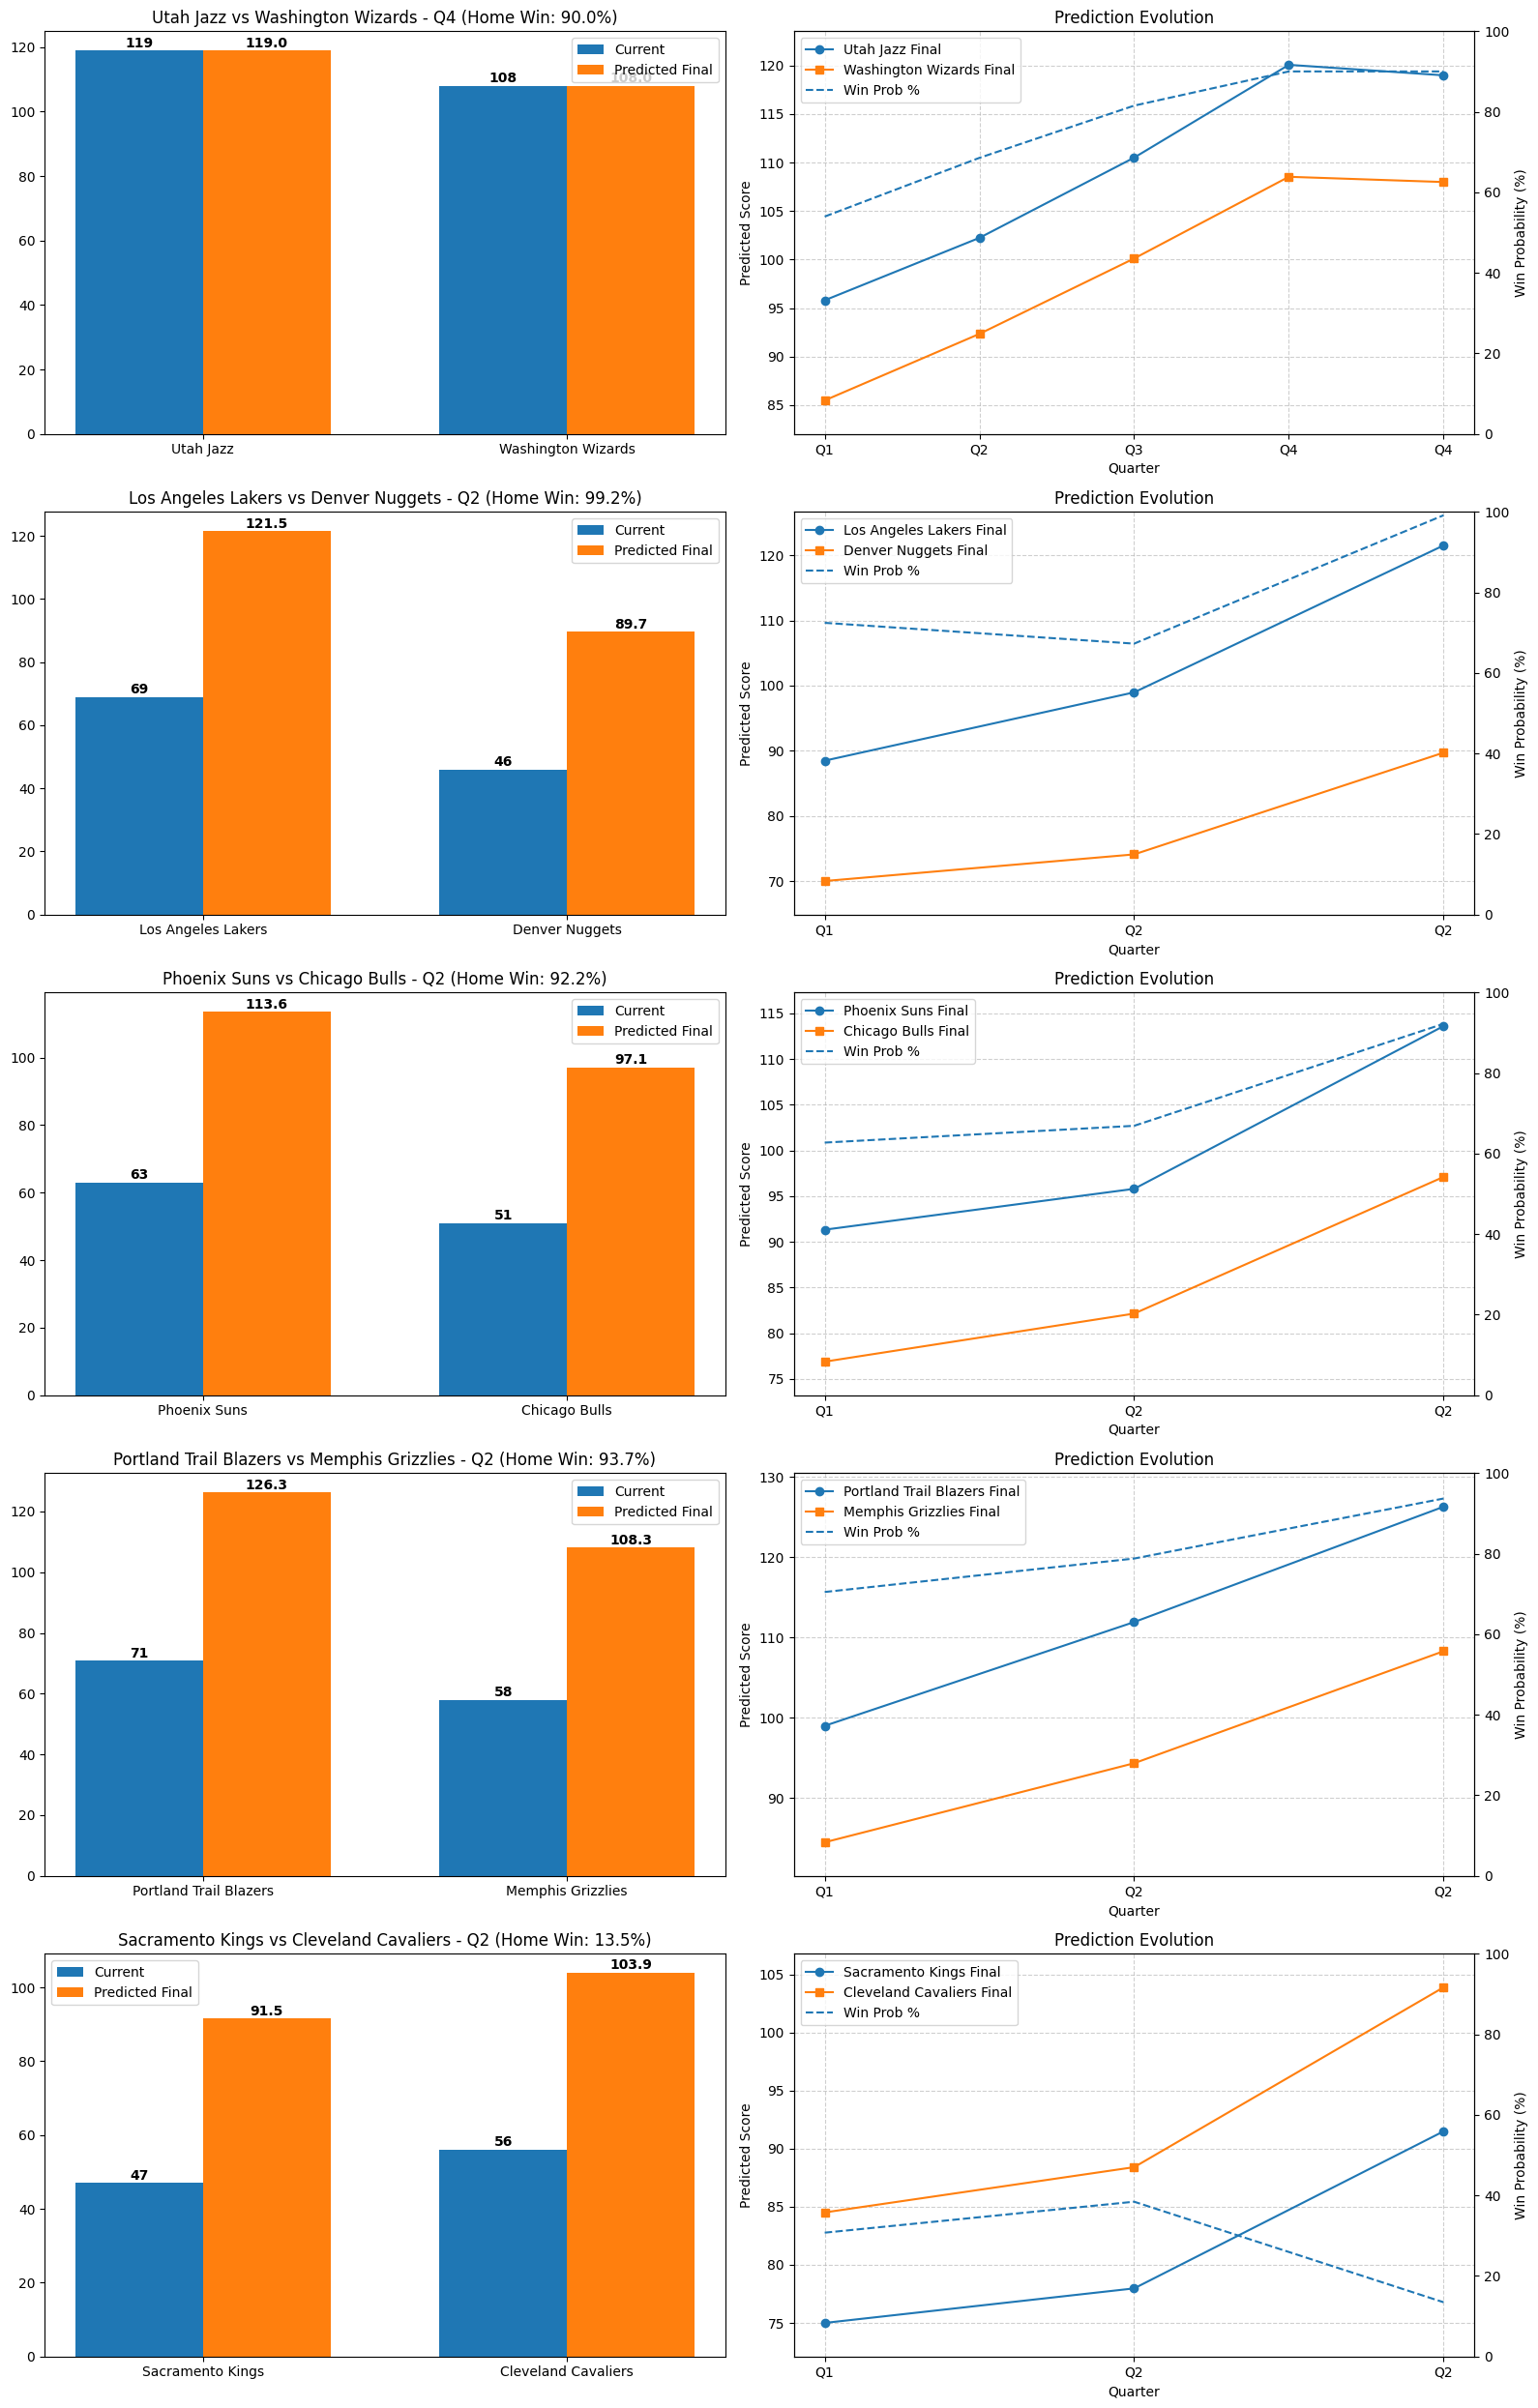


Game Predictions - 2025-03-19 23:32:58

Utah Jazz vs Washington Wizards - Quarter 4
Current Score: Utah Jazz 119 - Washington Wizards 108
Predicted Final: Utah Jazz 119.0 - Washington Wizards 108.0
Win Probability: 90.0%
--------------------------------------------------------------------------------

Los Angeles Lakers vs Denver Nuggets - Quarter 2
Current Score: Los Angeles Lakers 69 - Denver Nuggets 46
Predicted Final: Los Angeles Lakers 121.5 - Denver Nuggets 89.7
Win Probability: 99.2%
Momentum: Denver Nuggets (73%)
--------------------------------------------------------------------------------

Phoenix Suns vs Chicago Bulls - Quarter 2
Current Score: Phoenix Suns 63 - Chicago Bulls 51
Predicted Final: Phoenix Suns 113.6 - Chicago Bulls 97.1
Win Probability: 92.2%
Momentum: Chicago Bulls (40%)
--------------------------------------------------------------------------------

Portland Trail Blazers vs Memphis Grizzlies - Quarter 2
Current Score: Portland Trail Blazers 71 - Memphis

In [8]:
# Cell 6B - NBA Score Prediction Engine - Core Implementation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import traceback
import sys
import os
import pytz
from datetime import datetime, timedelta
from sqlalchemy import create_engine
from typing import Dict, List, Tuple, Optional, Union, Any
import pickle

# ==================== CONFIGURATION =====================

CONFIG = {
    "debug": False,
    "visualize_limit": 6,
    "lookback_days": 30,
    "max_rest_days": 10,
    "log_level": "INFO",
    "momentum_cap": 25,
    "momentum_normalize_factor": 15.0,
    "league_avg_score": 220,
    "team_abbreviations": {},
}

FEATURE_SETS = {
    "original": [
        'home_q1', 'home_q2', 'home_q3', 'home_q4',
        'score_ratio', 'rolling_home_score', 'rolling_away_score', 'prev_matchup_diff'
    ],
    "enhanced": [
        'home_q1', 'home_q2', 'home_q3', 'home_q4',
        'score_ratio', 'prev_matchup_diff',
        'rest_days_home', 'rest_days_away', 'rest_advantage',
        'is_back_to_back_home', 'is_back_to_back_away',
        'q1_to_q2_momentum', 'q2_to_q3_momentum', 'q3_to_q4_momentum', 'cumulative_momentum'
    ]
}

DEFAULT_FEATURE_VALUES = {
    'home_q1': 0, 'home_q2': 0, 'home_q3': 0, 'home_q4': 0,
    'score_ratio': 0.5, 'rolling_home_score': 105.0, 'rolling_away_score': 105.0,
    'prev_matchup_diff': 0, 'rest_days_home': 2, 'rest_days_away': 2,
    'rest_advantage': 0, 'is_back_to_back_home': 0, 'is_back_to_back_away': 0,
    'q1_to_q2_momentum': 0, 'q2_to_q3_momentum': 0, 'q3_to_q4_momentum': 0,
    'cumulative_momentum': 0
}

MODEL_PATHS = [
    'models/score_prediction_model.pkl',
    'final_xgb_model.pkl',
    'enhanced_xgb_model.pkl',
    'backend/models/score_prediction_model.pkl',
]

backend_dir = os.path.join(os.getcwd(), "backend")
if os.path.exists(backend_dir) and backend_dir not in sys.path:
    sys.path.append(backend_dir)

try:
    from caching.supabase_client import supabase
    import config
    if hasattr(config, 'MODEL_PATH') and config.MODEL_PATH:
        MODEL_PATHS.insert(0, config.MODEL_PATH)
except ImportError as e:
    class MockSupabase:
        def table(self, name):
            return self
        def select(self, cols=None):
            return self
        def eq(self, col, val):
            return self
        def gte(self, col, val):
            return self
        def lte(self, col, val):
            return self
        def limit(self, n):
            return self
        def order(self, col, desc=False):
            return self
        def execute(self):
            return type('obj', (object,), {'data': []})
    supabase = MockSupabase()
    config = type('obj', (object,), {'MODEL_PATH': 'models/score_prediction_model.pkl'})
    if CONFIG["debug"]:
        print(f"Using mock objects due to import error: {e}")

# ==================== LOGGING UTILITIES =====================

def log_message(message: str, level: str = "INFO") -> None:
    if level == "DEBUG" and not CONFIG["debug"]:
        return
    ts = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    print(f"[{ts}] {level}: {message}")

def handle_exception(e: Exception, context: str = "") -> None:
    log_message(f"Error in {context}: {str(e)}", "ERROR")
    if CONFIG["debug"]:
        traceback.print_exc()

# ==================== DATA PROCESSING FUNCTIONS =====================

def ensure_numeric_features(df: pd.DataFrame, feature_cols: List[str]) -> pd.DataFrame:
    result = df.copy()
    for col in feature_cols:
        if col not in result.columns:
            result[col] = DEFAULT_FEATURE_VALUES.get(col, 0)
        result[col] = pd.to_numeric(result[col], errors='coerce').fillna(DEFAULT_FEATURE_VALUES.get(col, 0))
    return result

def calculate_derived_features(df: pd.DataFrame) -> pd.DataFrame:
    result_df = df.copy()
    result_df = calculate_current_scores(result_df)
    result_df = calculate_score_ratio(result_df)
    result_df['score_differential'] = result_df['home_score'] - result_df['away_score']
    result_df = calculate_momentum_features(result_df)
    result_df['time_remaining_mins'] = result_df['current_quarter'].apply(
        lambda q: max(0, 48 - ((int(q) - 1) * 12 + 6))
    )
    result_df['time_remaining_norm'] = result_df['time_remaining_mins'] / 48.0
    return result_df

def calculate_current_scores(df: pd.DataFrame) -> pd.DataFrame:
    result_df = df.copy()
    quarters = ['home_q1', 'home_q2', 'home_q3', 'home_q4']

    for q in quarters:
        if q in result_df.columns:
            result_df[q] = pd.to_numeric(result_df[q], errors='coerce').fillna(0)

    mask = (result_df['home_score'].isna()) | (result_df['home_score'] == 0)
    if mask.any():
        existing_quarters = [q for q in quarters if q in result_df.columns]
        if existing_quarters:
            result_df.loc[mask, 'home_score'] = result_df.loc[mask, existing_quarters].sum(axis=1)

    away_quarters = ['away_q1', 'away_q2', 'away_q3', 'away_q4']
    for q in away_quarters:
        if q in result_df.columns:
            result_df[q] = pd.to_numeric(result_df[q], errors='coerce').fillna(0)

    mask = (result_df['away_score'].isna()) | (result_df['away_score'] == 0)
    if mask.any():
        existing_quarters = [q for q in away_quarters if q in result_df.columns]
        if existing_quarters:
            result_df.loc[mask, 'away_score'] = result_df.loc[mask, existing_quarters].sum(axis=1)

    return result_df

def calculate_score_ratio(df: pd.DataFrame) -> pd.DataFrame:
    result_df = df.copy()
    home_scores = pd.to_numeric(result_df['home_score'], errors='coerce').fillna(0)
    away_scores = pd.to_numeric(result_df['away_score'], errors='coerce').fillna(0)
    total_scores = home_scores + away_scores

    result_df['score_ratio'] = 0.5
    mask = (total_scores > 0)
    if mask.any():
        result_df.loc[mask, 'score_ratio'] = home_scores[mask] / total_scores[mask]

    return result_df

def calculate_momentum_features(df: pd.DataFrame) -> pd.DataFrame:
    result_df = df.copy()
    momentum_cap = CONFIG["momentum_cap"]
    norm_factor = CONFIG["momentum_normalize_factor"]

    for col in ['q1_to_q2_momentum', 'q2_to_q3_momentum', 'q3_to_q4_momentum', 'cumulative_momentum']:
        result_df[col] = 0.0

    for team in ['home', 'away']:
        for q in range(1, 5):
            col = f'{team}_q{q}'
            if col in result_df.columns:
                result_df[col] = pd.to_numeric(result_df[col], errors='coerce').fillna(0)

    current_quarters = pd.to_numeric(result_df['current_quarter'], errors='coerce').fillna(0).astype(int)

    mask = (current_quarters >= 2)
    if mask.any():
        result_df.loc[mask, 'q1_to_q2_momentum'] = (
            (result_df.loc[mask, 'home_q2'] - result_df.loc[mask, 'home_q1']) -
            (result_df.loc[mask, 'away_q2'] - result_df.loc[mask, 'away_q1'])
        ).clip(-momentum_cap, momentum_cap)

    mask = (current_quarters >= 3)
    if mask.any():
        result_df.loc[mask, 'q2_to_q3_momentum'] = (
            (result_df.loc[mask, 'home_q3'] - result_df.loc[mask, 'home_q2']) -
            (result_df.loc[mask, 'away_q3'] - result_df.loc[mask, 'away_q2'])
        ).clip(-momentum_cap, momentum_cap)

    mask = (current_quarters >= 4)
    if mask.any():
        result_df.loc[mask, 'q3_to_q4_momentum'] = (
            (result_df.loc[mask, 'home_q4'] - result_df.loc[mask, 'home_q3']) -
            (result_df.loc[mask, 'away_q4'] - result_df.loc[mask, 'away_q3'])
        ).clip(-momentum_cap, momentum_cap)

    weights = [0.2, 0.3, 0.5]

    mask = (current_quarters == 2)
    if mask.any():
        result_df.loc[mask, 'cumulative_momentum'] = (
            result_df.loc[mask, 'q1_to_q2_momentum'] / norm_factor
        )

    mask = (current_quarters == 3)
    if mask.any():
        q1_to_q2 = result_df.loc[mask, 'q1_to_q2_momentum']
        q2_to_q3 = result_df.loc[mask, 'q2_to_q3_momentum']
        weighted_momentum = (q1_to_q2 * weights[0] + q2_to_q3 * weights[1]) / (weights[0] + weights[1])
        result_df.loc[mask, 'cumulative_momentum'] = weighted_momentum / norm_factor

    mask = (current_quarters >= 4)
    if mask.any():
        q1_to_q2 = result_df.loc[mask, 'q1_to_q2_momentum']
        q2_to_q3 = result_df.loc[mask, 'q2_to_q3_momentum']
        q3_to_q4 = result_df.loc[mask, 'q3_to_q4_momentum']
        weighted_momentum = (q1_to_q2 * weights[0] + q2_to_q3 * weights[1] + q3_to_q4 * weights[2]) / sum(weights)
        result_df.loc[mask, 'cumulative_momentum'] = weighted_momentum / norm_factor

    result_df['cumulative_momentum'] = result_df['cumulative_momentum'].clip(-1.0, 1.0)
    return result_df

def calculate_improved_rest_features(df: pd.DataFrame, max_lookback_days: int = 30, max_rest_days: int = 10) -> pd.DataFrame:
    if df.empty:
        return df

    result_df = df.copy()
    if 'game_date' not in result_df.columns:
        result_df['rest_days_home'] = 2.0
        result_df['rest_days_away'] = 2.0
        result_df['is_back_to_back_home'] = 0
        result_df['is_back_to_back_away'] = 0
        result_df['rest_advantage'] = 0
        return result_df

    result_df['game_date'] = pd.to_datetime(result_df['game_date'], errors='coerce')
    pacific_tz = pytz.timezone("America/Los_Angeles")
    if result_df['game_date'].dt.tz is None:
        result_df['game_date'] = result_df['game_date'].dt.tz_localize(pacific_tz)
    else:
        result_df['game_date'] = result_df['game_date'].dt.tz_convert(pacific_tz)

    result_df = result_df.sort_values('game_date')
    result_df['rest_days_home'] = 2.0
    result_df['rest_days_away'] = 2.0
    result_df['is_back_to_back_home'] = 0
    result_df['is_back_to_back_away'] = 0

    home_games = result_df[['game_id', 'game_date', 'home_team']].rename(columns={'home_team': 'team'})
    home_games['is_home'] = True
    away_games = result_df[['game_id', 'game_date', 'away_team']].rename(columns={'away_team': 'team'})
    away_games['is_home'] = False
    all_games = pd.concat([home_games, away_games])

    teams = set(result_df['home_team'].dropna().unique()).union(set(result_df['away_team'].dropna().unique()))
    for team in teams:
        team_games = all_games[all_games['team'] == team].sort_values('game_date')
        if team_games.empty:
            continue

        team_games['prev_date'] = team_games['game_date'].shift(1)
        team_games['days_since_prev'] = (team_games['game_date'] - team_games['prev_date']).dt.days.fillna(3)
        team_games['days_since_prev'] = team_games['days_since_prev'].clip(1, max_rest_days)
        team_games['is_back_to_back'] = (team_games['days_since_prev'] == 1).astype(int)

        for _, row in team_games.iterrows():
            game_id = row['game_id']
            is_home = row['is_home']
            if is_home:
                idx = result_df.index[(result_df['game_id'] == game_id) & (result_df['home_team'] == team)]
                if not idx.empty:
                    result_df.loc[idx, 'rest_days_home'] = row['days_since_prev']
                    result_df.loc[idx, 'is_back_to_back_home'] = row['is_back_to_back']
            else:
                idx = result_df.index[(result_df['game_id'] == game_id) & (result_df['away_team'] == team)]
                if not idx.empty:
                    result_df.loc[idx, 'rest_days_away'] = row['days_since_prev']
                    result_df.loc[idx, 'is_back_to_back_away'] = row['is_back_to_back']

    result_df['rest_advantage'] = (result_df['rest_days_home'] - result_df['rest_days_away']).clip(-5, 5)
    return result_df

def generate_simulated_prediction_history(game: Dict) -> List[Dict]:
    """
    Generate simulated prediction history for visualization when real history is unavailable.
    This improved version ensures predictions are realistic basketball scores.
    """
    import random

    current_quarter = int(game.get('current_quarter', 0))
    current_home_score = float(game.get('home_score', 0))
    current_away_score = float(game.get('away_score', 0))

    final_home_prediction = float(game.get('predicted_home_score', 0))
    final_away_prediction = float(game.get('predicted_away_score', 0))

    if final_home_prediction < 80 or final_away_prediction < 80:
        if current_quarter > 0 and (current_home_score > 0 or current_away_score > 0):
            quarters_left = 4 - current_quarter
            if quarters_left > 0:
                points_per_quarter_home = current_home_score / current_quarter
                points_per_quarter_away = current_away_score / current_quarter
                final_home_prediction = current_home_score + (points_per_quarter_home * quarters_left)
                final_away_prediction = current_away_score + (points_per_quarter_away * quarters_left)
            else:
                final_home_prediction = current_home_score
                final_away_prediction = current_away_score
        else:
            final_home_prediction = 110
            final_away_prediction = 105

    win_probability = float(game.get('win_probability', 0.5))

    if current_quarter < 1:
        return [{
            'timestamp': datetime.now(),
            'current_quarter': current_quarter,
            'home_score': current_home_score,
            'away_score': current_away_score,
            'predicted_home_score': final_home_prediction,
            'predicted_away_score': final_away_prediction,
            'win_probability': win_probability
        }]

    history = []
    now = datetime.now()
    timestamps = [now - timedelta(minutes=15*i) for i in range(current_quarter+1)]
    timestamps.reverse()

    for q in range(1, current_quarter+1):
        q_ratio = q / 4.0
        simulated_home_score = current_home_score * q_ratio
        simulated_away_score = current_away_score * q_ratio
        pred_uncertainty = max(0.2, 1.0 - (q / 4.0))
        prediction_ratio = 0.7 + (0.3 * q / 4.0)
        base_factor = min(12, final_home_prediction * 0.1) * pred_uncertainty
        random_factor = random.uniform(-base_factor, base_factor)
        simulated_home_prediction = max(75, final_home_prediction * prediction_ratio + random_factor)
        final_spread = final_home_prediction - final_away_prediction
        current_spread = simulated_home_prediction - final_away_prediction * prediction_ratio
        spread_adjustment = (final_spread - current_spread) * (q / 4.0)
        simulated_away_prediction = max(70, simulated_home_prediction - final_spread * prediction_ratio - random_factor * 0.5)
        wp_shift = win_probability - 0.5
        initial_wp = 0.5 + (wp_shift * (q / 4.0))
        wp_random = random.uniform(-0.15, 0.15) * (1 - q/4.0)
        simulated_wp = max(min(initial_wp + wp_random, 0.99), 0.01)

        history.append({
            'timestamp': timestamps[q-1],
            'current_quarter': q,
            'home_score': simulated_home_score,
            'away_score': simulated_away_score,
            'predicted_home_score': simulated_home_prediction,
            'predicted_away_score': simulated_away_prediction,
            'win_probability': simulated_wp
        })

    history.append({
        'timestamp': timestamps[-1],
        'current_quarter': current_quarter,
        'home_score': current_home_score,
        'away_score': current_away_score,
        'predicted_home_score': final_home_prediction,
        'predicted_away_score': final_away_prediction,
        'win_probability': win_probability
    })

    return history

def calculate_adaptive_weights(current_quarter: int, score_differential: float, momentum: float,
                               main_model_error: Optional[float] = None, quarter_model_error: Optional[float] = None) -> Tuple[float, float]:
    base_quarter_weights = {0: 0.30, 1: 0.40, 2: 0.60, 3: 0.75, 4: 0.90}
    base_main_weight = base_quarter_weights.get(current_quarter, 0.5)

    adjustments = []
    if score_differential < 5:
        adjustments.append(-0.10)
    elif score_differential < 10:
        adjustments.append(-0.05)
    elif score_differential > 20:
        adjustments.append(0.10)
    elif score_differential > 15:
        adjustments.append(0.05)

    momentum_magnitude = abs(momentum)
    momentum_adjustment = -0.15 * momentum_magnitude
    adjustments.append(momentum_adjustment)

    if main_model_error is not None and quarter_model_error is not None:
        if main_model_error > 0 and quarter_model_error > 0:
            error_ratio = main_model_error / quarter_model_error
            error_adjustment = min(max(-0.15, (1.0 - error_ratio) * 0.2), 0.15)
            adjustments.append(error_adjustment)

    final_main_weight = base_main_weight + sum(adjustments)
    final_main_weight = max(0.1, min(0.95, final_main_weight))
    final_quarter_weight = 1.0 - final_main_weight

    return final_main_weight, final_quarter_weight

# ==================== NBA GAME PREDICTOR CLASS =====================

class CustomUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module.startswith("numpy._core"):
            module = module.replace("numpy._core", "numpy.core")
        return super().find_class(module, name)

def load_model_with_patch(model_path):
    with open(model_path, 'rb') as f:
        unpickler = CustomUnpickler(f)
        return unpickler.load()

class NBAGamePredictor:
    """
    Predict NBA game outcomes and generate visualizations and recommendations.
    """
    
    def __init__(self, config: Dict = None):
        self.model = None
        self.feature_list = None
        self.prediction_history = {}
        if config:
            for key, value in config.items():
                CONFIG[key] = value
        log_message("Initializing NBA Game Predictor")
        self.load_model()
    
    def load_model(self) -> None:
        import joblib
        import hashlib

        fallback_model_path = "fallback_model.pkl"
        if os.path.exists(fallback_model_path):
            log_message(f"Found fallback model file at {fallback_model_path}. Attempting to load it using standard joblib.load.")
            try:
                model = joblib.load(fallback_model_path, mmap_mode=None)
                if hasattr(model, 'predict') and callable(model.predict):
                    log_message(f"Successfully loaded fallback model from {fallback_model_path}")
                    self.model = model
                    self.feature_list = ['home_q1', 'home_q2', 'home_q3', 'home_q4']
                    if not hasattr(self.model, 'model_hash'):
                        with open(fallback_model_path, 'rb') as f:
                            self.model.model_hash = hashlib.md5(f.read()).hexdigest()
                    return
                else:
                    log_message(f"Fallback model loaded from {fallback_model_path} does not have a predict() method.", "WARNING")
            except Exception as e:
                log_message(f"Failed to load fallback model from {fallback_model_path}: {str(e)}", "WARNING")

        log_message("Fallback model not loaded. Attempting to load production model from configured paths.")
        model_paths = MODEL_PATHS.copy()
        model_paths.extend([os.path.join(os.getcwd(), path) for path in MODEL_PATHS])

        for path in model_paths:
            try:
                if os.path.exists(path):
                    log_message(f"Attempting to load model from {path}")
                    model = load_model_with_patch(path)
                    if hasattr(model, 'predict') and callable(model.predict):
                        log_message(f"Successfully loaded model from {path}")
                        self.model = model
                        try:
                            n_features = model.n_features_in_
                            if n_features == 4:
                                self.feature_list = ['home_q1', 'home_q2', 'home_q3', 'home_q4']
                                log_message("Model trained with 4 features; using minimal feature set.")
                            elif n_features > 8:
                                self.feature_list = FEATURE_SETS["enhanced"]
                                log_message(f"Model trained with {n_features} features; using enhanced feature set.")
                            else:
                                self.feature_list = FEATURE_SETS["original"]
                                log_message(f"Model trained with {n_features} features; using original feature set.")
                        except Exception as e:
                            log_message("Could not determine model feature count; defaulting to enhanced features.", "WARNING")
                            self.feature_list = FEATURE_SETS["enhanced"]
                        if not hasattr(self.model, 'model_hash'):
                            with open(path, 'rb') as f:
                                self.model.model_hash = hashlib.md5(f.read()).hexdigest()
                        return
                    else:
                        log_message(f"Loaded object from {path} lacks a predict() method.", "WARNING")
                else:
                    log_message(f"Model file not found at {path}", "DEBUG")
            except Exception as e:
                log_message(f"Failed to load model from {path}: {str(e)}", "WARNING")

        log_message("No model could be loaded. Creating fallback model...", "WARNING")
        self.create_fallback_model()

    def create_fallback_model(self) -> None:
        from sklearn.ensemble import GradientBoostingRegressor
        log_message("Creating fallback prediction model")
        model = GradientBoostingRegressor(n_estimators=50, random_state=42)
        np.random.seed(42)
        X = pd.DataFrame({
            'home_q1': np.random.randint(20, 30, 1000),
            'home_q2': np.random.randint(20, 30, 1000),
            'home_q3': np.random.randint(20, 30, 1000),
            'home_q4': np.random.randint(20, 30, 1000),
            'score_ratio': np.random.uniform(0.4, 0.6, 1000),
            'rolling_home_score': np.random.normal(106, 5, 1000),
            'rolling_away_score': np.random.normal(103, 5, 1000),
            'prev_matchup_diff': np.random.normal(3, 8, 1000)
        })
        y = X['home_q1'] + X['home_q2'] + X['home_q3'] + X['home_q4'] + np.random.normal(0, 5, 1000)
        model.fit(X, y)
        log_message("Fallback model created and trained")
        self.model = model
        self.feature_list = FEATURE_SETS["original"]
    
    def get_feature_list(self) -> List[str]:
        if self.feature_list is not None:
            return self.feature_list
        is_enhanced = False
        if self.model and hasattr(self.model, 'feature_importances_'):
            is_enhanced = len(self.model.feature_importances_) > 8
        self.feature_list = FEATURE_SETS["enhanced" if is_enhanced else "original"]
        log_message(f"Using {'enhanced' if is_enhanced else 'original'} feature set")
        return self.feature_list
    
    def fetch_live_games_pacific(self) -> pd.DataFrame:
        try:
            log_message("Fetching all games for today...")
            pacific_tz = pytz.timezone("America/Los_Angeles")
            now_pt = datetime.now(pacific_tz)
            today_pt = now_pt.date()
            start_pt = datetime.combine(today_pt, datetime.min.time()).replace(tzinfo=pacific_tz)
            end_pt = datetime.combine(today_pt, datetime.max.time()).replace(tzinfo=pacific_tz)
            start_iso = start_pt.strftime('%Y-%m-%dT%H:%M:%S')
            end_iso = end_pt.strftime('%Y-%m-%dT%H:%M:%S')
            log_message(f"Fetching games from Supabase in range: {start_iso} to {end_iso}")
            response = supabase.table("nba_live_game_stats").select("*").gte("game_date", start_iso).lte("game_date", end_iso).execute()
            if not response.data:
                log_message(f"No games found for today ({today_pt}).", "WARNING")
                return pd.DataFrame()
            df = pd.DataFrame(response.data)
            log_message(f"Found {len(df)} rows for today in the database.")

            df['game_date'] = pd.to_datetime(df['game_date'], errors='coerce')
            if df['game_date'].dt.tz is None:
                df['game_date'] = df['game_date'].dt.tz_localize(pacific_tz)
            else:
                df['game_date'] = df['game_date'].dt.tz_convert(pacific_tz)

            df['game_date_pt'] = df['game_date']
            df['date_only_pt'] = df['game_date_pt'].dt.date
            log_message(f"Today's date in PT: {today_pt}")

            df_today = df[df['date_only_pt'] == today_pt].copy()
            log_message(f"Rows matching today's PT date: {len(df_today)}")

            df_today = self.process_game_statuses(df_today)
            return df_today
        except Exception as e:
            handle_exception(e, "fetch_live_games_pacific")
            return pd.DataFrame()
    
    def process_game_statuses(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Mark games as 'live', 'completed', or 'pregame' based on status strings.
        Add more possible final statuses if your API provides them differently.
        """
        df = df.copy()
        live_statuses = {"Q1", "Q2", "Q3", "Q4", "OT", "BT", "HT"}
        completed_statuses = {"FINAL", "FINISHED", "COMPLETED", "END", "ENDED", "POST", "POSTGAME", "POST-GAME"}

        if "status" in df.columns:
            df["status"] = df["status"].astype(str).str.upper()
            df["game_status"] = df["status"].apply(
                lambda s: "live" if s in live_statuses
                          else "completed" if s in completed_statuses
                          else "pregame"
            )
            # Fix: If a game is marked as pregame but current_quarter is 4, mark it as completed.
            if "current_quarter" in df.columns:
                df.loc[
                    (df["game_status"] == "pregame") & 
                    (pd.to_numeric(df["current_quarter"], errors='coerce').fillna(0).astype(int) == 4),
                    "game_status"
                ] = "completed"
        else:
            df["game_status"] = "pregame"

        return df
    
    def fetch_recent_historical_data(self, lookback_days: int = 30) -> pd.DataFrame:
        try:
            db_url = getattr(config, 'DATABASE_URL', None)
            if not db_url:
                log_message("DATABASE_URL not found in config", "WARNING")
                return pd.DataFrame()
            engine = create_engine(db_url)
            cutoff_date = (datetime.now() - timedelta(days=lookback_days)).strftime('%Y-%m-%d')
            query = f"""
                SELECT * 
                FROM nba_historical_game_stats
                WHERE game_date >= '{cutoff_date}'
                ORDER BY game_date
            """
            hist_df = pd.read_sql(query, engine)
            log_message(f"Fetched {len(hist_df)} historical games from database")

            if 'game_date' in hist_df.columns:
                hist_df['game_date'] = pd.to_datetime(hist_df['game_date'], errors='coerce')
                pacific_tz = pytz.timezone("America/Los_Angeles")
                if hist_df['game_date'].dt.tz is None:
                    hist_df['game_date'] = hist_df['game_date'].dt.tz_localize(pacific_tz)
                else:
                    hist_df['game_date'] = hist_df['game_date'].dt.tz_convert(pacific_tz)
            return hist_df
        except Exception as e:
            handle_exception(e, "fetch_recent_historical_data")
            return pd.DataFrame()
    
    def predict_game_scores(self, df: pd.DataFrame) -> pd.DataFrame:
        if df.empty or self.model is None:
            return pd.DataFrame()

        expected_features = self.get_feature_list()
        X = df[expected_features].copy()
        predictions = self.model.predict(X)
        results = df.copy()
        
        results['predicted_home_score'] = predictions
        mask = (results['predicted_home_score'] < 80) | (results['predicted_home_score'].isna())
        if mask.any():
            log_message(f"Applying fallback predictions for {mask.sum()} games with unrealistic scores", "WARNING")
            results.loc[mask, 'predicted_home_score'] = 105.0
        
        current_time = datetime.now()
        
        for idx, row in results.iterrows():
            try:
                diff_weight = min(0.3 + (0.1 * row.get('current_quarter', 0)), 0.6)
                momentum_adj = row.get('cumulative_momentum', 0) * 3.0
                current_q = int(row.get('current_quarter', 0))
                home_score = float(row.get('home_score', 0))
                away_score = float(row.get('away_score', 0))
                current_diff = home_score - away_score
                predicted_diff = (row.get('prev_matchup_diff', 0) * diff_weight) + momentum_adj
                
                q_weight = min(current_q / 4.0, 1.0)
                final_diff = current_diff * q_weight + predicted_diff * (1 - q_weight)
                
                away_guess = results.at[idx, 'predicted_home_score'] - final_diff
                
                if current_q > 0:
                    quarters_remaining = 4 - current_q
                    if quarters_remaining > 0:
                        home_ppq = home_score / current_q
                        away_ppq = away_score / current_q
                        projected_home = home_score + (home_ppq * quarters_remaining)
                        projected_away = away_score + (away_ppq * quarters_remaining)
                        blend_factor = min(0.2 + (current_q * 0.2), 0.8)
                        results.at[idx, 'predicted_home_score'] = (
                            projected_home * blend_factor
                            + results.at[idx, 'predicted_home_score'] * (1 - blend_factor)
                        )
                        away_guess = (
                            projected_away * blend_factor
                            + away_guess * (1 - blend_factor)
                        )
                
                results.at[idx, 'predicted_home_score'] = max(results.at[idx, 'predicted_home_score'], home_score)
                results.at[idx, 'predicted_away_score'] = max(away_guess, away_score)
                
                if current_q < 3:
                    results.at[idx, 'predicted_home_score'] = max(results.at[idx, 'predicted_home_score'], 85)
                    results.at[idx, 'predicted_away_score'] = max(results.at[idx, 'predicted_away_score'], 80)
                
                max_score = 150
                results.at[idx, 'predicted_home_score'] = min(results.at[idx, 'predicted_home_score'], max_score)
                results.at[idx, 'predicted_away_score'] = min(results.at[idx, 'predicted_away_score'], max_score)
                
                results.at[idx, 'predicted_home_score'] = round(results.at[idx, 'predicted_home_score'], 1)
                results.at[idx, 'predicted_away_score'] = round(results.at[idx, 'predicted_away_score'], 1)
                
                diff = results.at[idx, 'predicted_home_score'] - results.at[idx, 'predicted_away_score']
                slope = 0.1 + 0.1 * (current_q / 4.0)
                wp = 1.0 / (1.0 + np.exp(-slope * diff))
                results.at[idx, 'win_probability'] = wp
                results.at[idx, 'projected_margin'] = diff
                results.at[idx, 'total_projected_score'] = (
                    results.at[idx, 'predicted_home_score'] + results.at[idx, 'predicted_away_score']
                )
                
                game_id = row.get('game_id')
                if game_id not in self.prediction_history:
                    self.prediction_history[game_id] = []
                
                self.prediction_history[game_id].append({
                    'timestamp': current_time,
                    'current_quarter': current_q,
                    'home_score': home_score,
                    'away_score': away_score,
                    'predicted_home_score': results.at[idx, 'predicted_home_score'],
                    'predicted_away_score': results.at[idx, 'predicted_away_score'],
                    'win_probability': wp
                })
            except Exception as e:
                log_message(f"Error in game prediction: {e}", "ERROR")
                results.at[idx, 'predicted_home_score'] = max(105, float(row.get('home_score', 0)) * 1.1)
                results.at[idx, 'predicted_away_score'] = max(100, float(row.get('away_score', 0)) * 1.1)
                results.at[idx, 'win_probability'] = 0.5
                results.at[idx, 'projected_margin'] = (
                    results.at[idx, 'predicted_home_score'] - results.at[idx, 'predicted_away_score']
                )
                results.at[idx, 'total_projected_score'] = (
                    results.at[idx, 'predicted_home_score'] + results.at[idx, 'predicted_away_score']
                )
        
        return results
    
    def visualize_predictions(self, predictions_df: pd.DataFrame) -> None:
        if predictions_df.empty:
            log_message("No predictions to visualize", "WARNING")
            return
        
        n_games = predictions_df.shape[0]
        fig, axs = plt.subplots(n_games, 2, figsize=(16, 5 * n_games))
        if n_games == 1:
            axs = np.array([axs])
        
        display_limit = CONFIG["visualize_limit"]
        if n_games > display_limit:
            log_message(f"Displaying first {display_limit} of {n_games} games for readability")
            predictions_to_display = predictions_df.iloc[:display_limit].copy()
        else:
            predictions_to_display = predictions_df.copy()
        
        for i, (_, game) in enumerate(predictions_to_display.iterrows()):
            ax_scores = axs[i, 0]
            teams = [game['home_team'], game['away_team']]
            current_scores = [float(game.get('home_score', 0)), float(game.get('away_score', 0))]
            predicted_scores = [float(game.get('predicted_home_score', 0)), float(game.get('predicted_away_score', 0))]
            
            x = np.arange(len(teams))
            width = 0.35
            ax_scores.bar(x - width/2, current_scores, width, label='Current')
            ax_scores.bar(x + width/2, predicted_scores, width, label='Predicted Final')
            
            for j, v in enumerate(current_scores):
                ax_scores.text(j - width/2, v + 1, f"{v:.0f}", ha='center', fontweight='bold')
            for j, v in enumerate(predicted_scores):
                ax_scores.text(j + width/2, v + 1, f"{v:.1f}", ha='center', fontweight='bold')
            
            cq = int(game.get('current_quarter', 0))
            if game.get('game_status', 'unknown') == 'completed':
                status_text = "Final"
            else:
                status_text = f"Q{cq}" if cq > 0 else "Pre-game"

            title = f"{game['home_team']} vs {game['away_team']} - {status_text}"
            if 'win_probability' in game:
                win_pct = game['win_probability'] * 100
                title += f" (Home Win: {win_pct:.1f}%)"
            
            ax_scores.set_title(title)
            ax_scores.set_xticks(x)
            ax_scores.set_xticklabels(teams)
            ax_scores.legend()
            
            ax_hist = axs[i, 1]
            gid = game.get('game_id', f'game_{i}')
            
            if gid in self.prediction_history and len(self.prediction_history[gid]) > 1:
                hist = self.prediction_history[gid]
                log_message(f"Using actual prediction history with {len(hist)} points", "DEBUG")
            else:
                hist = generate_simulated_prediction_history(game)
                log_message(f"Using simulated prediction history with {len(hist)} points", "DEBUG")
                self.prediction_history[gid] = hist
            
            hist_df = pd.DataFrame(hist)
            
            if len(hist_df) >= 1:
                x_vals = range(len(hist_df))
                ax_hist.plot(x_vals, hist_df['predicted_home_score'], 
                             label=f"{game['home_team']} Final", marker='o')
                ax_hist.plot(x_vals, hist_df['predicted_away_score'], 
                             label=f"{game['away_team']} Final", marker='s')
                
                min_score = min(hist_df['predicted_home_score'].min(), hist_df['predicted_away_score'].min())
                max_score = max(hist_df['predicted_home_score'].max(), hist_df['predicted_away_score'].max())
                y_padding = (max_score - min_score) * 0.1
                ax_hist.set_ylim(max(0, min_score - y_padding), max_score + y_padding)
                
                if 'win_probability' in hist_df.columns:
                    ax_wp = ax_hist.twinx()
                    ax_wp.plot(x_vals, hist_df['win_probability']*100, 
                               label='Win Prob %', linestyle='--')
                    ax_wp.set_ylabel("Win Probability (%)")
                    ax_wp.set_ylim(0, 100)
                    
                    lines, labels = ax_hist.get_legend_handles_labels()
                    lines2, labels2 = ax_wp.get_legend_handles_labels()
                    ax_hist.legend(lines + lines2, labels + labels2, loc='upper left')
                else:
                    ax_hist.legend(loc='upper left')
                
                ax_hist.set_title("Prediction Evolution")
                
                if 'current_quarter' in hist_df.columns:
                    ax_hist.set_xlabel("Quarter")
                    ax_hist.set_ylabel("Predicted Score")
                    x_labels = [f"Q{q}" for q in hist_df['current_quarter']]
                    ax_hist.set_xticks(x_vals)
                    ax_hist.set_xticklabels(x_labels)
                else:
                    ax_hist.set_xlabel("Update #")
                    ax_hist.set_ylabel("Predicted Score")
                    ax_hist.set_xticks(x_vals)
                    ax_hist.set_xticklabels([f"#{i+1}" for i in x_vals])
                    
                ax_hist.grid(True, linestyle='--', alpha=0.6)
            else:
                ax_hist.text(0.5, 0.5, "No prediction history yet", 
                             ha='center', va='center', transform=ax_hist.transAxes, fontsize=12)
        
        plt.tight_layout()
        plt.show()
        self.print_prediction_summary(predictions_df)
    
    def print_prediction_summary(self, predictions_df: pd.DataFrame) -> pd.DataFrame:
        print(f"\nGame Predictions - {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
        print("=" * 80)
        for i, (_, game) in enumerate(predictions_df.iterrows()):
            counter = f"[{i+1}/{len(predictions_df)}] " if len(predictions_df) > 10 else ""
            
            if game.get('game_status', 'unknown') == 'completed':
                status_text = "Final"
            else:
                cq = int(game.get('current_quarter', 0))
                status_text = f"Quarter {cq}" if cq > 0 else "Pre-game"

            print(f"\n{counter}{game['home_team']} vs {game['away_team']} - {status_text}")
            
            home_score = float(game.get('home_score', 0))
            away_score = float(game.get('away_score', 0))
            if status_text.startswith("Quarter"):
                print(f"Current Score: {game['home_team']} {home_score:.0f} - {game['away_team']} {away_score:.0f}")
            
            pred_home = float(game.get('predicted_home_score', 0))
            pred_away = float(game.get('predicted_away_score', 0))
            
            if (pred_home < 10 or pred_away < 10) and (home_score > 0 or away_score > 0):
                cq = int(game.get('current_quarter', 0))
                if cq > 0:
                    quarters_left = 4 - cq
                    points_per_quarter_home = home_score / cq
                    points_per_quarter_away = away_score / cq
                    pred_home = home_score + (points_per_quarter_home * quarters_left)
                    pred_away = away_score + (points_per_quarter_away * quarters_left)
                else:
                    pred_home = 110
                    pred_away = 105
            
            predictions_df.loc[predictions_df.index[i], 'predicted_home_score'] = pred_home
            predictions_df.loc[predictions_df.index[i], 'predicted_away_score'] = pred_away
            
            print(f"Predicted Final: {game['home_team']} {pred_home:.1f} - {game['away_team']} {pred_away:.1f}")
            
            wp = float(game.get('win_probability', 0.5))
            if wp < 0.01:
                wp = 0.5 + (0.15 * (1 if pred_home > pred_away else -1))
                predictions_df.loc[predictions_df.index[i], 'win_probability'] = wp
            print(f"Win Probability: {wp*100:.1f}%")
            
            if 'cumulative_momentum' in game and abs(game.get('cumulative_momentum', 0)) > 0.2:
                team_with_momentum = game['home_team'] if game['cumulative_momentum'] > 0 else game['away_team']
                print(f"Momentum: {team_with_momentum} ({abs(game['cumulative_momentum'])*100:.0f}%)")
            
            predictions_df.loc[predictions_df.index[i], 'projected_margin'] = pred_home - pred_away
            predictions_df.loc[predictions_df.index[i], 'total_projected_score'] = pred_home + pred_away
            
            if i >= 9 and len(predictions_df) > 10:
                remaining = len(predictions_df) - 10
                print(f"\n... and {remaining} more games (not shown for brevity)")
                break
            print("-"*80)
        
        return predictions_df
    
    def print_game_status_summary(self, status_groups: Dict[str, pd.DataFrame]) -> None:
        print("\nGame Status Summary:")
        print("=" * 80)
        for status in status_groups:
            print(f"{status.upper()}: {len(status_groups[status])} games")
            for idx, game in status_groups[status].iterrows():
                home = game['home_team']
                away = game['away_team']
                home_score = game.get('home_score', 0)
                away_score = game.get('away_score', 0)
                if status == 'pregame':
                    print(f"  • {home} vs {away} (Upcoming)")
                elif status == 'completed':
                    print(f"  • {home} {home_score:.0f} - {away_score:.0f} {away} (Final)")
                else:
                    print(f"  • {home} {home_score:.0f} - {away_score:.0f} {away}")
        print("=" * 80)
    
    def generate_recommendations(self, predictions_df: pd.DataFrame) -> Dict[str, Dict[str, str]]:
        recs = {}
        league_avg = CONFIG["league_avg_score"]
        for _, game in predictions_df.iterrows():
            game_key = f"{game['home_team']} vs {game['away_team']}"
            home_score = float(game.get('home_score', 0))
            away_score = float(game.get('away_score', 0))
            pred_home = float(game.get('predicted_home_score', 0))
            pred_away = float(game.get('predicted_away_score', 0))
            
            if (pred_home < 10 or pred_away < 10) and (home_score > 0 or away_score > 0):
                quarter = int(game.get('current_quarter', 0))
                if quarter > 0:
                    quarters_left = 4 - quarter
                    points_per_quarter_home = home_score / quarter
                    points_per_quarter_away = away_score / quarter
                    pred_home = home_score + (points_per_quarter_home * quarters_left)
                    pred_away = away_score + (points_per_quarter_away * quarters_left)
                else:
                    pred_home = 110
                    pred_away = 105
            
            wp = float(game.get('win_probability', 0.5))
            if wp < 0.01:
                wp = 0.5 + (0.15 * (1 if pred_home > pred_away else -1))
            
            momentum = float(game.get('cumulative_momentum', 0))
            margin = pred_home - pred_away
            total_pts = pred_home + pred_away
            quarter = int(game.get('current_quarter', 0))
            
            tips = {}
            if quarter >= 3 and wp > 0.9:
                tips["betting_tip"] = f"Strong confidence in {game['home_team']} win ({wp*100:.1f}%)"
            elif wp > 0.75:
                tips["betting_tip"] = f"Home advantage favors {game['home_team']} ({wp*100:.1f}%)"
            elif wp < 0.3:
                tips["betting_tip"] = f"Consider {game['away_team']} for upset ({(1-wp)*100:.1f}%)"
            else:
                tips["betting_tip"] = "Competitive game; consider hedging."
                
            if momentum > 0.3:
                tips["momentum_advice"] = f"Strong momentum for {game['home_team']}"
            elif momentum < -0.3:
                tips["momentum_advice"] = f"Strong momentum for {game['away_team']}"
            else:
                tips["momentum_advice"] = "Momentum appears balanced."
                
            if abs(margin) >= 8:
                fav = game['home_team'] if margin > 0 else game['away_team']
                tips["spread_tip"] = f"{fav} projected to cover by {abs(margin):.1f} points."
            else:
                tips["spread_tip"] = f"Tight margin projected ({abs(margin):.1f} points)."
                
            if total_pts > league_avg + 10:
                tips["over_under_tip"] = f"High-scoring game likely ({total_pts:.1f} points)."
            elif total_pts < league_avg - 10:
                tips["over_under_tip"] = f"Low-scoring game likely ({total_pts:.1f} points)."
            else:
                tips["over_under_tip"] = f"Projected total: {total_pts:.1f} points."
                
            if quarter == 4 and abs(margin) < 6:
                tips["clutch_tip"] = "Close game in final minutes – monitor closely."
                
            if quarter < 2:
                tips["early_game_tip"] = "Early game – watch for adjustments."
                
            tips["predicted_final"] = f"Projected final: {game['home_team']} {pred_home:.1f} - {game['away_team']} {pred_away:.1f}"
            recs[game_key] = tips
            
        return recs
    
    def run_full_prediction_pipeline(self) -> pd.DataFrame:
        try:
            log_message("Starting prediction pipeline...")
            log_message("Fetching today's games...")
            games_df = self.fetch_live_games_pacific()
            if games_df.empty:
                log_message("No games available for today", "WARNING")
                return pd.DataFrame()

            log_message(f"Processing {len(games_df)} games by status:")
            status_groups = {}
            for status in ['live', 'pregame', 'completed', 'unknown']:
                subset = games_df[games_df['game_status'] == status]
                if not subset.empty:
                    status_groups[status] = subset
                    log_message(f"  - {status.upper()}: {len(subset)} games")

            log_message("Fetching historical data for rest calculations...")
            hist_df = self.fetch_recent_historical_data(lookback_days=CONFIG["lookback_days"])
            log_message("Calculating rest features and preparing games...")
            today_games = calculate_improved_rest_features(games_df, max_rest_days=CONFIG["max_rest_days"])
            log_message("Calculating game features...")
            today_games = calculate_derived_features(today_games)
            expected = self.get_feature_list()
            today_games = ensure_numeric_features(today_games, expected)
            log_message("Generating predictions...")
            predictions_df = self.predict_game_scores(today_games)
            if predictions_df.empty:
                log_message("No predictions generated", "WARNING")
                return pd.DataFrame()
                
            to_visualize = None
            if 'live' in status_groups:
                log_message("Preparing live game predictions...")
                to_visualize = predictions_df[predictions_df['game_status'] == 'live']
            elif 'pregame' in status_groups:
                log_message("No live games. Preparing pregame predictions...")
                to_visualize = predictions_df[predictions_df['game_status'] == 'pregame']
            elif 'completed' in status_groups:
                log_message("Preparing completed game results...")
                to_visualize = predictions_df[predictions_df['game_status'] == 'completed'].head(CONFIG["visualize_limit"])

            self.print_game_status_summary(status_groups)
            self.print_prediction_summary(predictions_df)

            if to_visualize is not None and not to_visualize.empty:
                print(f"\nShowing predictions for {len(to_visualize)} games:")
                self.visualize_predictions(to_visualize)
            else:
                print("\nNo games to visualize")
                
            for status in ['live', 'pregame', 'completed', 'unknown']:
                subset = games_df[games_df['game_status'] == status]
                if not subset.empty:
                    status_groups[status] = subset
                    log_message(f"  - {status.upper()}: {len(subset)} games")

            self.print_game_recommendations(status_groups)
            return predictions_df
        except Exception as e:
            handle_exception(e, "run_full_prediction_pipeline")
            return pd.DataFrame()
    
    def print_game_recommendations(self, status_groups: Dict[str, pd.DataFrame]) -> None:
        if 'live' in status_groups and not status_groups['live'].empty:
            live_recs = self.generate_recommendations(status_groups['live'])
            print("\nLive Game Recommendations:")
            print("=" * 80)
            for game_name, rec in live_recs.items():
                print(f"\n{game_name}:")
                for k, v in rec.items():
                    print(f"  • {k}: {v}")
                print("-" * 40)

        if 'pregame' in status_groups and not status_groups['pregame'].empty:
            pregame_recs = self.generate_recommendations(status_groups['pregame'])
            print("\nPregame Recommendations:")
            print("=" * 80)
            for game_name, rec in pregame_recs.items():
                print(f"\n{game_name}:")
                for k, v in rec.items():
                    print(f"  • {k}: {v}")
                print("-" * 40)

# ==================== MAIN EXECUTION =====================

if __name__ == "__main__":
    predictor_config = {
        "debug": False,
        "visualize_limit": 6,
        "lookback_days": 30,
    }
    predictor = NBAGamePredictor(predictor_config)
    predictions = predictor.run_full_prediction_pipeline()


In [ ]:
# Cell 9: Enhanced Prediction Evolution Visualization with Plotly

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
import numpy as np
from datetime import datetime
import math

def calculate_confidence_intervals(prediction, quarter, score_differential=None, momentum=None):
    """
    Calculate confidence intervals based on game state.
    
    Args:
        prediction: Predicted score value
        quarter: Current quarter (0-4)
        score_differential: Points difference between teams (optional)
        momentum: Momentum value between -1 and 1 (optional)
        
    Returns:
        tuple: (lower_bound, upper_bound)
    """
    # Base confidence width based on quarter
    base_width = {
        0: 15.0,  # Pre-game: widest interval
        1: 12.0,  # Q1: still wide
        2: 8.0,   # Q2: narrower
        3: 5.0,   # Q3: getting more confident
        4: 3.0    # Q4: narrowest interval
    }.get(quarter, 10.0)
    
    # Adjust based on score differential if provided
    differential_factor = 1.0
    if score_differential is not None:
        # Close games (within 5 points) have wider intervals
        if abs(score_differential) < 5:
            differential_factor = 1.2
        # Blowouts (15+ points) have narrower intervals
        elif abs(score_differential) > 15:
            differential_factor = 0.8
    
    # Adjust based on momentum if provided
    momentum_factor = 1.0
    if momentum is not None:
        # High momentum (either direction) indicates less predictability
        if abs(momentum) > 0.6:
            momentum_factor = 1.2
    
    # Calculate interval width with all factors
    interval_width = base_width * differential_factor * momentum_factor
    
    # Return bounds
    lower_bound = prediction - interval_width
    upper_bound = prediction + interval_width
    
    return lower_bound, upper_bound

def create_prediction_evolution_chart(prediction_history, selected_game_id=None, max_games=3):
    """
    Create interactive prediction evolution visualization with Plotly.
    
    Args:
        prediction_history: Dictionary of game predictions over time
        selected_game_id: ID of game to highlight (optional)
        max_games: Maximum number of games to display
        
    Returns:
        plotly.graph_objects.Figure
    """
    # Handle empty history
    if not prediction_history:
        fig = go.Figure()
        fig.add_annotation(
            text="No prediction history available",
            showarrow=False,
            font=dict(size=16),
            xref="paper", yref="paper",
            x=0.5, y=0.5
        )
        return fig
    
    # Determine which games to plot
    if selected_game_id and selected_game_id in prediction_history:
        # Just plot the selected game
        games_to_plot = {selected_game_id: prediction_history[selected_game_id]}
    else:
        # Get the most recent/active games up to max_games
        games_to_plot = {}
        # Sort games by recency of last update
        sorted_games = sorted(
            prediction_history.items(),
            key=lambda x: x[1][-1].get('timestamp', datetime.now()) if x[1] else datetime.now(),
            reverse=True
        )
        for game_id, history in sorted_games[:max_games]:
            games_to_plot[game_id] = history
    
    # Handle zero games case
    if not games_to_plot:
        fig = go.Figure()
        fig.add_annotation(
            text="No suitable games found in prediction history",
            showarrow=False,
            font=dict(size=16),
            xref="paper", yref="paper",
            x=0.5, y=0.5
        )
        return fig
    
    # Determine subplot layout based on number of games
    num_games = len(games_to_plot)
    rows = min(num_games, 2)  # Max 2 rows
    cols = math.ceil(num_games / rows)
    
    # Create subplot figure
    fig = make_subplots(
        rows=rows, cols=cols,
        subplot_titles=[f"{history[0].get('home_team', 'Home')} vs {history[0].get('away_team', 'Away')}" 
                        if history else f"Game {game_id}" 
                        for game_id, history in games_to_plot.items()],
        specs=[[{"secondary_y": True} for _ in range(cols)] for _ in range(rows)]
    )
    
    # Plot each game
    idx = 0
    for game_id, history in games_to_plot.items():
        if not history:
            continue
        
        # Calculate row and column for this game
        row = (idx // cols) + 1
        col = (idx % cols) + 1
        
        # Extract data
        update_indices = list(range(len(history)))
        quarters = [point.get('current_quarter', 0) for point in history]
        home_scores = [point.get('predicted_home_score', 0) for point in history]
        away_scores = [point.get('predicted_away_score', 0) for point in history]
        win_probs = [point.get('win_probability', 0.5) for point in history]
        
        # Calculate confidence intervals for home and away predictions
        home_lower = []
        home_upper = []
        away_lower = []
        away_upper = []
        
        for i, point in enumerate(history):
            quarter = point.get('current_quarter', 0)
            score_diff = (point.get('current_home_score', 0) or 0) - (point.get('current_away_score', 0) or 0)
            momentum = point.get('momentum_shift', 0) or point.get('cumulative_momentum', 0) or 0
            
            h_lower, h_upper = calculate_confidence_intervals(home_scores[i], quarter, score_diff, momentum)
            a_lower, a_upper = calculate_confidence_intervals(away_scores[i], quarter, -score_diff, -momentum)
            
            home_lower.append(h_lower)
            home_upper.append(h_upper)
            away_lower.append(a_lower)
            away_upper.append(a_upper)
        
        # Get team names
        home_team = history[0].get('home_team', 'Home Team')
        away_team = history[0].get('away_team', 'Away Team')
        
        # Add home team prediction with confidence interval
        fig.add_trace(
            go.Scatter(
                x=update_indices,
                y=home_scores,
                mode='lines+markers',
                name=f"{home_team} Prediction",
                line=dict(color='blue', width=3),
                hovertemplate="Update %{x}<br>" +
                             f"{home_team}: %{{y:.1f}}<br>" +
                             "Quarter: %{text}<extra></extra>",
                text=quarters
            ),
            row=row, col=col
        )
        
        # Add home team confidence interval
        fig.add_trace(
            go.Scatter(
                x=update_indices + update_indices[::-1],
                y=home_upper + home_lower[::-1],
                fill='toself',
                fillcolor='rgba(0, 0, 255, 0.1)',
                line=dict(color='rgba(0, 0, 255, 0)'),
                hoverinfo="skip",
                showlegend=False,
                name=f"{home_team} Confidence"
            ),
            row=row, col=col
        )
        
        # Add away team prediction with confidence interval
        fig.add_trace(
            go.Scatter(
                x=update_indices,
                y=away_scores,
                mode='lines+markers',
                name=f"{away_team} Prediction",
                line=dict(color='red', width=3),
                hovertemplate="Update %{x}<br>" +
                             f"{away_team}: %{{y:.1f}}<br>" +
                             "Quarter: %{text}<extra></extra>",
                text=quarters
            ),
            row=row, col=col
        )
        
        # Add away team confidence interval
        fig.add_trace(
            go.Scatter(
                x=update_indices + update_indices[::-1],
                y=away_upper + away_lower[::-1],
                fill='toself',
                fillcolor='rgba(255, 0, 0, 0.1)',
                line=dict(color='rgba(255, 0, 0, 0)'),
                hoverinfo="skip",
                showlegend=False,
                name=f"{away_team} Confidence"
            ),
            row=row, col=col
        )
        
        # Add win probability on secondary y-axis
        fig.add_trace(
            go.Scatter(
                x=update_indices,
                y=[wp * 100 for wp in win_probs],
                mode='lines+markers',
                name=f"{home_team} Win Probability",
                line=dict(color='green', width=2, dash='dash'),
                marker=dict(symbol='diamond'),
                hovertemplate="Update %{x}<br>" +
                             f"{home_team} Win: %{{y:.1f}}%<br>" +
                             "Quarter: %{text}<extra></extra>",
                text=quarters
            ),
            secondary_y=True,
            row=row, col=col
        )
        
        # Add current quarter markers at the top
        for i, quarter in enumerate(quarters):
            if i > 0 and quarter != quarters[i-1]:
                fig.add_shape(
                    type="line",
                    x0=i, x1=i,
                    y0=min(min(home_lower), min(away_lower)),
                    y1=max(max(home_upper), max(away_upper)),
                    line=dict(color="gray", width=1, dash="dot"),
                    row=row, col=col
                )
                
                fig.add_annotation(
                    x=i,
                    y=max(max(home_upper), max(away_upper)),
                    text=f"Q{quarter}",
                    showarrow=False,
                    yshift=10,
                    row=row, col=col
                )
        
        # Add annotations for the latest predictions
        if history:
            latest = history[-1]
            latest_home = latest.get('predicted_home_score', 0)
            latest_away = latest.get('predicted_away_score', 0)
            latest_quarter = latest.get('current_quarter', 0)
            
            # Format the quarter text
            quarter_text = "Pre-game" if latest_quarter == 0 else f"Q{latest_quarter}"
            
            # Add a floating annotation with the current prediction
            fig.add_annotation(
                x=len(history) - 1,
                y=max(latest_home, latest_away) + 5,
                text=f"Latest ({quarter_text}): {home_team} {latest_home:.1f} - {away_team} {latest_away:.1f}",
                showarrow=True,
                arrowhead=1,
                arrowcolor="black",
                ax=0,
                ay=-40,
                bgcolor="rgba(255,255,255,0.8)",
                bordercolor="black",
                borderwidth=1,
                row=row, col=col
            )
        
        # Update layout for this subplot
        fig.update_xaxes(title_text="Update Index", row=row, col=col)
        fig.update_yaxes(title_text="Predicted Score", row=row, col=col)
        fig.update_yaxes(title_text="Win Probability (%)", secondary_y=True, 
                          range=[0, 100], row=row, col=col)
        
        idx += 1
    
    # Update overall layout
    fig.update_layout(
        title="Prediction Evolution Over Time",
        height=400 * rows,
        width=600 * cols,
        legend=dict(
            orientation="h",
            yanchor="bottom",
            y=1.02,
            xanchor="right",
            x=1
        ),
        margin=dict(l=60, r=60, t=80, b=60)
    )
    
    return fig

def create_live_game_dashboard(predictions_df, prediction_history=None):
    """
    Create an interactive dashboard for live games with Plotly.
    
    Args:
        predictions_df: DataFrame with current game predictions
        prediction_history: Dictionary of prediction history over time
        
    Returns:
        plotly.graph_objects.Figure
    """
    if predictions_df.empty:
        fig = go.Figure()
        fig.add_annotation(
            text="No live games available",
            showarrow=False,
            font=dict(size=16),
            xref="paper", yref="paper",
            x=0.5, y=0.5
        )
        return fig
    
    # Determine number of games
    n_games = len(predictions_df)
    rows = min(n_games, 3)  # Max 3 rows
    cols = 2  # Always 2 columns (current score + prediction evolution)
    
    # Create subplot figure
    fig = make_subplots(
        rows=rows, cols=cols,
        subplot_titles=[f"{row['home_team']} vs {row['away_team']} (Q{row['current_quarter']})" 
                        for _, row in predictions_df.iterrows()],
        specs=[[{"type": "bar"}, {"secondary_y": True}] for _ in range(rows)]
    )
    
    # Process each game
    for i, (_, game) in enumerate(predictions_df.iterrows()):
        row = i + 1
        game_id = game.get('game_id', f"game_{i}")
        
        # Extract data for current scores and predictions
        teams = [game['home_team'], game['away_team']]
        current_scores = [float(game.get('current_home_score', game.get('home_score', 0)) or 0),
                          float(game.get('current_away_score', game.get('away_score', 0)) or 0)]
        predicted_scores = [float(game['predicted_home_score']), float(game['predicted_away_score'])]
        
        # Calculate confidence intervals
        home_lower, home_upper = calculate_confidence_intervals(
            predicted_scores[0], 
            game['current_quarter'],
            current_scores[0] - current_scores[1],
            game.get('momentum_shift', 0) or game.get('cumulative_momentum', 0) or 0
        )
        
        away_lower, away_upper = calculate_confidence_intervals(
            predicted_scores[1], 
            game['current_quarter'],
            current_scores[1] - current_scores[0],
            -(game.get('momentum_shift', 0) or game.get('cumulative_momentum', 0) or 0)
        )
        
        # Create confidence interval text
        home_ci_text = f"±{(home_upper - home_lower)/2:.1f}"
        away_ci_text = f"±{(away_upper - away_lower)/2:.1f}"
        
        # Add current scores
        fig.add_trace(
            go.Bar(
                x=teams,
                y=current_scores,
                name="Current Score",
                marker_color=['royalblue', 'firebrick'],
                text=current_scores,
                textposition='auto',
                hovertemplate="%{x}<br>Current: %{y}<extra></extra>"
            ),
            row=row, col=1
        )
        
        # Add predicted scores with error bars
        fig.add_trace(
            go.Bar(
                x=teams,
                y=predicted_scores,
                name="Predicted Final",
                marker_color=['lightskyblue', 'lightcoral'],
                text=[f"{predicted_scores[0]:.1f} {home_ci_text}", 
                      f"{predicted_scores[1]:.1f} {away_ci_text}"],
                textposition='auto',
                error_y=dict(
                    type='data',
                    array=[(home_upper - predicted_scores[0]), 
                           (away_upper - predicted_scores[1])],
                    arrayminus=[(predicted_scores[0] - home_lower), 
                                (predicted_scores[1] - away_lower)],
                    visible=True
                ),
                hovertemplate="%{x}<br>Predicted: %{y:.1f}<br>Range: %{text}<extra></extra>"
            ),
            row=row, col=1
        )
        
        # Add win probability annotation
        if 'win_probability' in game:
            win_prob = game['win_probability'] * 100
            winner = game['home_team'] if win_prob > 50 else game['away_team']
            win_prob_text = f"{winner} Win: {max(win_prob, 100-win_prob):.1f}%"
            
            fig.add_annotation(
                x=0.5, y=-0.15,
                xref=f"x domain", yref=f"y domain",
                text=win_prob_text,
                showarrow=False,
                font=dict(size=12, color="black"),
                bgcolor="rgba(255,255,255,0.8)",
                bordercolor="black",
                borderwidth=1,
                row=row, col=1
            )
        
        # Add prediction history if available
        if prediction_history and game_id in prediction_history:
            history = prediction_history[game_id]
            
            # Extract data for evolution chart
            update_indices = list(range(len(history)))
            quarters = [pt.get('current_quarter', 0) for pt in history]
            home_scores = [pt.get('predicted_home_score', 0) for pt in history]
            away_scores = [pt.get('predicted_away_score', 0) for pt in history]
            win_probs = [pt.get('win_probability', 0.5) for pt in history]
            
            # Add home prediction evolution
            fig.add_trace(
                go.Scatter(
                    x=update_indices,
                    y=home_scores,
                    mode='lines+markers',
                    name=f"{game['home_team']} Prediction",
                    line=dict(color='blue'),
                    hovertemplate="Update %{x}<br>Predicted: %{y:.1f}<br>Quarter: %{text}<extra></extra>",
                    text=quarters
                ),
                row=row, col=2
            )
            
            # Add away prediction evolution
            fig.add_trace(
                go.Scatter(
                    x=update_indices,
                    y=away_scores,
                    mode='lines+markers',
                    name=f"{game['away_team']} Prediction",
                    line=dict(color='red'),
                    hovertemplate="Update %{x}<br>Predicted: %{y:.1f}<br>Quarter: %{text}<extra></extra>",
                    text=quarters
                ),
                row=row, col=2
            )
            
            # Add win probability evolution
            fig.add_trace(
                go.Scatter(
                    x=update_indices,
                    y=[wp * 100 for wp in win_probs],
                    mode='lines+markers',
                    name="Win Probability",
                    line=dict(color='green', dash='dash'),
                    hovertemplate="Update %{x}<br>Win Prob: %{y:.1f}%<br>Quarter: %{text}<extra></extra>",
                    text=quarters
                ),
                secondary_y=True,
                row=row, col=2
            )
            
            # Update layout for evolution chart
            fig.update_xaxes(title_text="Update Index", row=row, col=2)
            fig.update_yaxes(title_text="Predicted Score", row=row, col=2)
            fig.update_yaxes(title_text="Win Probability (%)", secondary_y=True, 
                             range=[0, 100], row=row, col=2)
        else:
            # Add a placeholder
            fig.add_annotation(
                x=0.5, y=0.5,
                xref=f"x{row*2} domain", yref=f"y{row*2} domain",
                text="Not enough prediction history",
                showarrow=False,
                font=dict(size=12),
                row=row, col=2
            )
    
    # Update overall layout
    fig.update_layout(
        height=350 * rows,
        showlegend=False,
        margin=dict(l=50, r=50, t=30, b=50)
    )
    
    return fig

# Example usage (mock data for testing)
if __name__ == "__main__":
    # Create sample prediction history for testing
    sample_history = {
        "game1": [
            {'home_team': 'Lakers', 'away_team': 'Celtics', 'current_quarter': 1, 
             'predicted_home_score': 105.5, 'predicted_away_score': 102.3, 'win_probability': 0.58,
             'current_home_score': 25, 'current_away_score': 22, 'timestamp': datetime.now()},
            {'home_team': 'Lakers', 'away_team': 'Celtics', 'current_quarter': 2, 
             'predicted_home_score': 107.2, 'predicted_away_score': 103.1, 'win_probability': 0.62,
             'current_home_score': 52, 'current_away_score': 48, 'timestamp': datetime.now()},
            {'home_team': 'Lakers', 'away_team': 'Celtics', 'current_quarter': 3, 
             'predicted_home_score': 110.5, 'predicted_away_score': 105.8, 'win_probability': 0.65,
             'current_home_score': 78, 'current_away_score': 74, 'timestamp': datetime.now()}
        ],
        "game2": [
            {'home_team': 'Warriors', 'away_team': 'Bucks', 'current_quarter': 1, 
             'predicted_home_score': 112.5, 'predicted_away_score': 110.3, 'win_probability': 0.52,
             'current_home_score': 30, 'current_away_score': 29, 'timestamp': datetime.now()},
            {'home_team': 'Warriors', 'away_team': 'Bucks', 'current_quarter': 2, 
             'predicted_home_score': 115.2, 'predicted_away_score': 112.1, 'win_probability': 0.56,
             'current_home_score': 58, 'current_away_score': 55, 'timestamp': datetime.now()}
        ]
    }
    
    # Create sample current predictions dataframe
    sample_predictions = pd.DataFrame([
        {'game_id': 'game1', 'home_team': 'Lakers', 'away_team': 'Celtics', 'current_quarter': 3,
         'home_score': 78, 'away_score': 74, 'current_home_score': 78, 'current_away_score': 74,
         'predicted_home_score': 110.5, 'predicted_away_score': 105.8, 'win_probability': 0.65},
        {'game_id': 'game2', 'home_team': 'Warriors', 'away_team': 'Bucks', 'current_quarter': 2,
         'home_score': 58, 'away_score': 55, 'current_home_score': 58, 'current_away_score': 55,
         'predicted_home_score': 115.2, 'predicted_away_score': 112.1, 'win_probability': 0.56}
    ])
    
    # Create and display the figures
    evolution_fig = create_prediction_evolution_chart(sample_history)
    dashboard_fig = create_live_game_dashboard(sample_predictions, sample_history)
    
    # In a Jupyter notebook, you would display these with:
    # evolution_fig.show()
    # dashboard_fig.show()

In [ ]:
# Cell 10: Data Fetching Functions

def get_team_rolling_averages(days_lookback: int = 60) -> dict:
    try:
        threshold_date = (datetime.now() - timedelta(days=days_lookback)).strftime('%Y-%m-%d')
        response = supabase.table("nba_historical_game_stats").select("*").gte("game_date", threshold_date).execute()
        if not response.data:
            print(f"No historical game data available from the last {days_lookback} days.")
            return {}
        df = pd.DataFrame(response.data)
        df['game_date'] = pd.to_datetime(df['game_date'])
        df = df.sort_values('game_date')
        team_avgs = {}
        all_teams = set(df['home_team'].unique()).union(set(df['away_team'].unique()))
        for team in all_teams:
            home = df[df['home_team'] == team]['home_score']
            away = df[df['away_team'] == team]['away_score']
            all_scores = pd.concat([home, away])
            team_avgs[team] = all_scores.mean() if not all_scores.empty else 105.0
        return team_avgs
    except Exception as e:
        print(f"Error getting team rolling averages: {e}")
        traceback.print_exc()
        return {}

def get_previous_matchup_diff(home_team: str, away_team: str, max_lookback: int = 5) -> float:
    try:
        response_home = supabase.table("nba_historical_game_stats").select("*")\
            .eq("home_team", home_team).eq("away_team", away_team)\
            .order('game_date', desc=True).limit(max_lookback).execute()
        response_away = supabase.table("nba_historical_game_stats").select("*")\
            .eq("home_team", away_team).eq("away_team", home_team)\
            .order('game_date', desc=True).limit(max_lookback).execute()
        matchups = (response_home.data or []) + (response_away.data or [])
        if matchups:
            matchups.sort(key=lambda x: x['game_date'], reverse=True)
            matchups = matchups[:max_lookback]
            diffs = []
            for game in matchups:
                if game['home_team'] == home_team and game['away_team'] == away_team:
                    diffs.append(game['home_score'] - game['away_score'])
                elif game['home_team'] == away_team and game['away_team'] == home_team:
                    diffs.append(game['away_score'] - game['home_score'])
            return np.mean(diffs) if diffs else 0
        return 0
    except Exception as e:
        print(f"Error getting previous matchups: {e}")
        return 0


In [ ]:
# Cell 13: Enhanced Model Validation with Structured Results and Cross-Validation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import os
from datetime import datetime, timedelta
from typing import Dict, List, Tuple, Optional, Any
from sklearn.model_selection import KFold
import traceback
import pickle

class ModelValidator:
    """
    Enhanced model validation framework for NBA score prediction models with
    cross-validation support and structured results reporting.
    """
    
    def __init__(self, supabase_client=None, model=None):
        """
        Initialize the model validator.
        
        Args:
            supabase_client: Supabase client for data access
            model: Pre-trained prediction model to validate
        """
        self.supabase = supabase_client
        self.model = model
        self.results_directory = './validation_results'
        # Create results directory if it doesn't exist
        os.makedirs(self.results_directory, exist_ok=True)
    
    def validate_on_historical_games(self, 
                                num_games: int = 10, 
                                model_override=None, 
                                team_avgs: Optional[Dict[str, float]] = None,
                                visualize: bool = True,
                                cross_validate: bool = False,
                                n_splits: int = 5) -> Dict[str, Any]:
        """
        Validate the prediction model on historical games with structured results.
        """
        print("Starting validation on historical games...")
        validation_results = {
            'timestamp': datetime.now().isoformat(),
            'num_games': num_games,
            'cross_validation': cross_validate,
            'n_splits': n_splits if cross_validate else None,
            'overall_metrics': {},
            'quarter_metrics': {},
            'game_results': [],
            'error_distribution': {},
            'cross_val_results': [] if cross_validate else None
        }
        
        try:
            model_to_use = model_override if model_override is not None else self.model
            if model_to_use is None:
                print("No prediction model loaded. Skipping validation.")
                validation_results['error'] = "No model available"
                return validation_results
            
            historical_games = self._fetch_historical_games(num_games)
            if historical_games.empty:
                print("No historical games found for validation.")
                validation_results['error'] = "No historical games found"
                return validation_results
            
            if team_avgs is None:
                team_avgs = self._get_team_rolling_averages()
            
            if cross_validate:
                cv_results = self._perform_cross_validation(historical_games, model_to_use, team_avgs, n_splits)
                validation_results['cross_val_results'] = cv_results
                if not cv_results:
                    # No folds had data
                    print("No cross-validation results computed.")
                    validation_results['overall_metrics'] = {}
                else:
                    validation_results['overall_metrics'] = {
                        'mean_absolute_error': float(np.mean([r['mean_absolute_error'] for r in cv_results])),
                        'root_mean_squared_error': float(np.mean([r['root_mean_squared_error'] for r in cv_results])),
                        'winner_accuracy': float(np.mean([r['winner_accuracy'] for r in cv_results])),
                        # Watch for folds that omitted 'r2_score' if you add that
                    }
            else:
                all_results = []
                print(f"Validating model on {len(historical_games)} games")
                for idx, game in historical_games.iterrows():
                    quarter_results = self._validate_game_by_quarters(game, model_to_use, team_avgs)
                    game_result = {
                        'game_id': game['game_id'],
                        'home_team': game['home_team'],
                        'away_team': game['away_team'],
                        'actual_home_score': game['home_score'],
                        'actual_away_score': game['away_score'],
                        'actual_margin': game['home_score'] - game['away_score'],
                        'actual_winner': 'home' if game['home_score'] > game['away_score'] else 'away',
                        'quarter_results': quarter_results
                    }
                    all_results.append(game_result)
                
                validation_results['game_results'] = all_results
                validation_results['quarter_metrics'] = self._calculate_quarter_metrics(all_results)
                validation_results['overall_metrics'] = self._calculate_overall_metrics(all_results)
                validation_results['error_distribution'] = self._calculate_error_distribution(all_results)

            if visualize:
                self.visualize_validation_results(validation_results)
            
            return validation_results
        except Exception as e:
            print(f"Error during validation: {e}")
            traceback.print_exc()
            validation_results['error'] = str(e)
            validation_results['traceback'] = traceback.format_exc()
            return validation_results
    
    def _fetch_historical_games(self, num_games: int) -> pd.DataFrame:
        """Fetch historical games from Supabase."""
        try:
            if self.supabase is None:
                print("No Supabase client provided. Cannot fetch games.")
                return pd.DataFrame()
            response = self.supabase.table("nba_historical_game_stats") \
                .select("*") \
                .order('game_date', desc=True) \
                .limit(num_games) \
                .execute()
            if not response.data:
                return pd.DataFrame()
            return pd.DataFrame(response.data)
        except Exception as e:
            print(f"Error fetching historical games: {e}")
            return pd.DataFrame()
    
    def _get_team_rolling_averages(self) -> Dict[str, float]:
        """Placeholder for team rolling averages (returns empty dict)."""
        try:
            if self.supabase is None:
                return {}
            return {}
        except Exception as e:
            print(f"Error calculating team averages: {e}")
            return {}
    
    def _validate_game_by_quarters(self, game: pd.Series, model: Any, team_avgs: Dict[str, float]) -> List[Dict[str, Any]]:
        quarter_results = []
        actual_home = game['home_score']
        actual_away = game['away_score']
        for quarter in range(1, 5):
            sim_game = {
                'game_id': game['game_id'],
                'home_team': game['home_team'],
                'away_team': game['away_team'],
                'game_date': game.get('game_date'),
                'current_quarter': quarter
            }
            home_score = sum(float(game.get(f'home_q{q}', 0)) for q in range(1, quarter+1))
            away_score = sum(float(game.get(f'away_q{q}', 0)) for q in range(1, quarter+1))
            sim_game['home_score'] = home_score
            sim_game['away_score'] = away_score
            for q in range(1, 5):
                sim_game[f'home_q{q}'] = float(game.get(f'home_q{q}', 0)) if q <= quarter else 0
                sim_game[f'away_q{q}'] = float(game.get(f'away_q{q}', 0)) if q <= quarter else 0
            sim_df = pd.DataFrame([sim_game])
            try:
                pred_result = self._run_prediction(sim_df, model, team_avgs)
                if pred_result.empty:
                    continue
                pred_row = pred_result.iloc[0]
                predicted_home = float(pred_row['predicted_home_score'])
                predicted_away = float(pred_row['predicted_away_score'])
                home_error = predicted_home - actual_home
                away_error = predicted_away - actual_away
                abs_error = (abs(home_error) + abs(away_error)) / 2
                actual_winner = 'home' if actual_home > actual_away else 'away'
                predicted_winner = 'home' if predicted_home > predicted_away else 'away'
                quarter_result = {
                    'quarter': quarter,
                    'current_home_score': home_score,
                    'current_away_score': away_score,
                    'predicted_home_score': predicted_home,
                    'predicted_away_score': predicted_away,
                    'predicted_margin': predicted_home - predicted_away,
                    'predicted_winner': predicted_winner,
                    'home_error': home_error,
                    'away_error': away_error,
                    'absolute_error': abs_error,
                    'pct_error_home': (abs(home_error) / actual_home) * 100 if actual_home > 0 else float('inf'),
                    'pct_error_away': (abs(away_error) / actual_away) * 100 if actual_away > 0 else float('inf'),
                    'winner_correct': actual_winner == predicted_winner
                }
                quarter_results.append(quarter_result)
            except Exception as e:
                print(f"Error validating quarter {quarter} for game {game['game_id']}: {e}")
        return quarter_results
    
    def _run_prediction(self, game_df: pd.DataFrame, model: Any, team_avgs: Dict[str, float]) -> pd.DataFrame:
        try:
            result_df = game_df.copy()
            # This is a simple simulation. Replace with your actual prediction logic.
            for idx, row in result_df.iterrows():
                current_quarter = int(row['current_quarter'])
                home_score = float(row.get('home_score', 0))
                away_score = float(row.get('away_score', 0))
                remaining_factor = 1.0 - (current_quarter / 4.0)
                home_team = row['home_team']
                away_team = row['away_team']
                home_avg = team_avgs.get(home_team, 105)
                away_avg = team_avgs.get(away_team, 105)
                predicted_home = home_score + (home_avg * remaining_factor)
                predicted_away = away_score + (away_avg * remaining_factor)
                result_df.at[idx, 'predicted_home_score'] = predicted_home
                result_df.at[idx, 'predicted_away_score'] = predicted_away
            return result_df
        except Exception as e:
            print(f"Error running prediction: {e}")
            return pd.DataFrame()
    
    def _calculate_quarter_metrics(self, game_results: List[Dict[str, Any]]) -> Dict[int, Dict[str, float]]:
        quarter_metrics = {q: {'mae': [], 'rmse': [], 'winner_accuracy': []} for q in range(1, 5)}
        for game in game_results:
            for qr in game['quarter_results']:
                q = qr['quarter']
                if q in quarter_metrics:
                    quarter_metrics[q]['mae'].append(qr['absolute_error'])
                    quarter_metrics[q]['rmse'].append(qr['absolute_error'] ** 2)
                    quarter_metrics[q]['winner_accuracy'].append(int(qr['winner_correct']))
        results = {}
        for q, metrics in quarter_metrics.items():
            if metrics['mae']:
                results[q] = {
                    'mean_absolute_error': np.mean(metrics['mae']),
                    'root_mean_squared_error': np.sqrt(np.mean(metrics['rmse'])),
                    'winner_accuracy': np.mean(metrics['winner_accuracy']),
                    'sample_size': len(metrics['mae'])
                }
        return results
    
    def _calculate_overall_metrics(self, game_results: List[Dict[str, Any]]) -> Dict[str, float]:
        all_maes = []
        all_mses = []
        all_winner_correct = []
        for game in game_results:
            for qr in game['quarter_results']:
                all_maes.append(qr['absolute_error'])
                all_mses.append(qr['absolute_error'] ** 2)
                all_winner_correct.append(int(qr['winner_correct']))
        if not all_maes:
            return {}
        return {
            'mean_absolute_error': np.mean(all_maes),
            'root_mean_squared_error': np.sqrt(np.mean(all_mses)),
            'winner_accuracy': np.mean(all_winner_correct),
            'sample_size': len(all_maes)
        }
    def _perform_cross_validation(self, games_df: pd.DataFrame, model: Any, team_avgs: Dict[str, float], n_splits: int = 5) -> List[Dict[str, Any]]:
        print(f"Performing {n_splits}-fold cross-validation...")
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
        cv_results = []
        for fold, (train_idx, test_idx) in enumerate(kf.split(games_df)):
            print(f"Processing fold {fold+1}/{n_splits}")
            train_games = games_df.iloc[train_idx]
            test_games = games_df.iloc[test_idx]
            
            # If model has a fit method, try to train
            if hasattr(model, 'fit'):
                X_train, y_train = self._prepare_training_data(train_games)
                if X_train is not None and y_train is not None:
                    model.fit(X_train, y_train)
            
            fold_results = []
            for idx, game in test_games.iterrows():
                quarter_results = self._validate_game_by_quarters(game, model, team_avgs)
                if quarter_results:
                    fold_results.extend(quarter_results)
            
            if len(fold_results) == 0:
                print(f"No data in fold {fold+1}; skipping metrics.")
                continue
            
            # If we have data, compute metrics
            all_abs = [r['absolute_error'] for r in fold_results]
            all_sq = [val**2 for val in all_abs]
            all_win = [int(r['winner_correct']) for r in fold_results]
            
            fold_metrics = {
                'fold': fold + 1,
                'train_size': len(train_games),
                'test_size': len(test_games),
                'mean_absolute_error': float(np.mean(all_abs)),  # cast to float for JSON
                'root_mean_squared_error': float(np.sqrt(np.mean(all_sq))),
                'winner_accuracy': float(np.mean(all_win)),
                'error_std_dev': float(np.std(all_abs)),
                'sample_size': len(all_abs)
            }
            cv_results.append(fold_metrics)
        
        return cv_results

    def _calculate_error_distribution(self, game_results: List[Dict[str, Any]]) -> Dict[str, Any]:
        all_errors = []
        for game in game_results:
            for qr in game['quarter_results']:
                all_errors.append(qr['absolute_error'])
        if not all_errors:
            return {}
        return {
            'min': np.min(all_errors),
            'max': np.max(all_errors),
            'median': np.median(all_errors),
            'p25': np.percentile(all_errors, 25),
            'p75': np.percentile(all_errors, 75),
            'p90': np.percentile(all_errors, 90),
            'std_dev': np.std(all_errors)
        }
    
    def _perform_cross_validation(self, games_df: pd.DataFrame, model: Any, team_avgs: Dict[str, float], n_splits: int = 5) -> List[Dict[str, Any]]:
        print(f"Performing {n_splits}-fold cross-validation...")
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
        cv_results = []
        for fold, (train_idx, test_idx) in enumerate(kf.split(games_df)):
            print(f"Processing fold {fold+1}/{n_splits}")
            train_games = games_df.iloc[train_idx]
            test_games = games_df.iloc[test_idx]
            if hasattr(model, 'fit'):
                X_train, y_train = self._prepare_training_data(train_games)
                if X_train is not None and y_train is not None:
                    model.fit(X_train, y_train)
            fold_results = []
            for idx, game in test_games.iterrows():
                quarter_results = self._validate_game_by_quarters(game, model, team_avgs)
                if quarter_results:
                    fold_results.extend(quarter_results)
            if fold_results:
                all_abs = [r['absolute_error'] for r in fold_results]
                all_sq = [r['absolute_error'] ** 2 for r in fold_results]
                all_win = [int(r['winner_correct']) for r in fold_results]
                fold_metrics = {
                    'fold': fold + 1,
                    'train_size': len(train_games),
                    'test_size': len(test_games),
                    'mean_absolute_error': np.mean(all_abs),
                    'root_mean_squared_error': np.sqrt(np.mean(all_sq)),
                    'winner_accuracy': np.mean(all_win),
                    'error_std_dev': np.std(all_abs),
                    'sample_size': len(all_abs)
                }
                cv_results.append(fold_metrics)
        return cv_results
    
    def _prepare_training_data(self, train_games: pd.DataFrame) -> Tuple[Optional[pd.DataFrame], Optional[pd.Series]]:
        # Placeholder: Replace with actual training data preparation
        return None, None
    
    def visualize_validation_results(self, validation_results: Dict[str, Any]):
        if not validation_results.get('quarter_metrics'):
            print("No metrics available for visualization.")
            return
        plt.figure(figsize=(12, 6))
        quarters = sorted(validation_results['quarter_metrics'].keys())
        maes = [validation_results['quarter_metrics'][q]['mean_absolute_error'] for q in quarters]
        rmses = [validation_results['quarter_metrics'][q]['root_mean_squared_error'] for q in quarters]
        accuracies = [validation_results['quarter_metrics'][q]['winner_accuracy'] * 100 for q in quarters]
        sample_sizes = [validation_results['quarter_metrics'][q]['sample_size'] for q in quarters]
        plt.subplot(1, 2, 1)
        width = 0.35
        x = np.arange(len(quarters))
        plt.bar(x - width/2, maes, width, label='MAE', color='skyblue')
        plt.bar(x + width/2, rmses, width, label='RMSE', color='salmon')
        for i, (m, s) in enumerate(zip(maes, sample_sizes)):
            plt.text(i - width/2, m + 0.5, f"n={s}", ha='center', va='bottom', fontsize=9)
        plt.xlabel('Quarter')
        plt.ylabel('Error (points)')
        plt.title('Error by Quarter')
        plt.xticks(x, quarters)
        plt.legend()
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.subplot(1, 2, 2)
        plt.plot(quarters, accuracies, 'o-', color='green', linewidth=2)
        for i, acc in enumerate(accuracies):
            plt.text(quarters[i], acc + 2, f"{acc:.1f}%", ha='center')
        plt.xlabel('Quarter')
        plt.ylabel('Winner Accuracy (%)')
        plt.title('Winner Accuracy by Quarter')
        plt.ylim(0, 100)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    
    def save_validation_results(self, validation_results: Dict[str, Any], filename: Optional[str] = None):
        if filename is None:
            timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
            filename = f"validation_results_{timestamp}.json"
        filepath = os.path.join(self.results_directory, filename)
        try:
            with open(filepath, 'w') as f:
                json.dump(validation_results, f, indent=2)
            print(f"Validation results saved to {filepath}")
            return filepath
        except Exception as e:
            print(f"Error saving validation results: {e}")
            return None
    
    def load_validation_results(self, filename: str) -> Dict[str, Any]:
        filepath = os.path.join(self.results_directory, filename)
        try:
            with open(filepath, 'r') as f:
                validation_results = json.load(f)
            print(f"Validation results loaded from {filepath}")
            return validation_results
        except Exception as e:
            print(f"Error loading validation results: {e}")
            return {}

# Usage example for demo validation
def demo_model_validation(model=None, supabase=None):
    """Demonstrate the enhanced model validation framework."""
    validator = ModelValidator(supabase_client=supabase, model=model)
    print("Running standard validation...")
    validation_results = validator.validate_on_historical_games(
        num_games=10,
        model_override=model,
        visualize=True,
        cross_validate=False
    )
    validator.save_validation_results(validation_results)
    print("\nRunning cross-validation...")
    cv_results = validator.validate_on_historical_games(
        num_games=5,
        model_override=model,
        visualize=True,
        cross_validate=True,
        n_splits=3
    )
    validator.save_validation_results(cv_results, "cross_validation_results.json")
    return {'validator': validator, 'standard_results': validation_results, 'cv_results': cv_results}

# Direct execution example
if __name__ == "__main__":
    try:
        from config import DATABASE_URL
        import joblib
        # Try to set up Supabase connection
        try:
            from caching.supabase_client import supabase
            print("Using existing Supabase connection")
        except ImportError:
            print("Supabase client not available. Running with simulation only.")
            supabase = None
        
        # Instantiate NBAGamePredictor (which loads the model)
        predictor = NBAGamePredictor()
        if predictor.model is not None:
            try:
                model_hash = predictor.model.model_hash  # Try to access if exists
            except AttributeError:
                # If missing, compute and assign hash
                with open("fallback_model.pkl", 'rb') as f:
                    predictor.model.model_hash = joblib.hash(f.read())
                model_hash = predictor.model.model_hash
            print(f"Loaded {type(predictor.model).__name__} model with hash: {model_hash}")
        else:
            print("No model loaded. Running with simulation only.")
        
        demo_results = demo_model_validation(model=predictor.model, supabase=supabase)
    except Exception as e:
        print(f"Error during demo: {e}")
        traceback.print_exc()


In [ ]:
# Cell 14: Fetch Scheduled Game Data with Centralized Timezone Handling

import pytz
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import time
import traceback
from functools import lru_cache
from typing import Dict, List, Optional, Tuple, Union

# ---- Timezone Utility Functions ----

def get_pacific_time():
    """Get current time in Pacific timezone."""
    pacific_tz = pytz.timezone('America/Los_Angeles')
    return datetime.now(pacific_tz)

def get_pacific_date_str():
    """Get current date in Pacific timezone as YYYY-MM-DD string."""
    return get_pacific_time().strftime('%Y-%m-%d')

def convert_to_pacific(dt, from_timezone=None):
    """Convert datetime to Pacific timezone.
    
    Args:
        dt: Datetime to convert (string or datetime object)
        from_timezone: Source timezone if dt is naive
        
    Returns:
        Timezone-aware datetime in Pacific time
    """
    pacific_tz = pytz.timezone('America/Los_Angeles')
    
    # Handle string dates
    if isinstance(dt, str):
        try:
            # If time component is missing, assume start of day
            if len(dt) <= 10:  # YYYY-MM-DD format
                dt_obj = datetime.strptime(dt, '%Y-%m-%d')
                # Add typical NBA game start time (7:30 PM Pacific)
                dt_obj = dt_obj.replace(hour=19, minute=30)
                # Localize to Pacific time
                return pacific_tz.localize(dt_obj)
            else:
                # Parse with time component
                dt_obj = pd.to_datetime(dt)
                # If timezone naive, localize to provided timezone or UTC
                if dt_obj.tzinfo is None:
                    source_tz = pytz.timezone(from_timezone) if from_timezone else pytz.UTC
                    dt_obj = source_tz.localize(dt_obj)
                # Convert to Pacific
                return dt_obj.astimezone(pacific_tz)
        except Exception as e:
            print(f"Error parsing date '{dt}': {e}")
            return get_pacific_time()
    
    # Handle datetime objects
    if isinstance(dt, datetime):
        # If timezone naive, localize to provided timezone or UTC
        if dt.tzinfo is None:
            source_tz = pytz.timezone(from_timezone) if from_timezone else pytz.UTC
            dt = source_tz.localize(dt)
        # Convert to Pacific
        return dt.astimezone(pacific_tz)
    
    # Default fallback
    print(f"Unsupported date format: {dt}")
    return get_pacific_time()

# ---- Caching Mechanism ----

# Cache for schedule data (expires after 30 minutes)
SCHEDULE_CACHE = {}
CACHE_EXPIRY = 30 * 60  # 30 minutes in seconds

def get_cached_data(key, expiry=CACHE_EXPIRY):
    """Get data from cache if it exists and hasn't expired."""
    if key in SCHEDULE_CACHE:
        timestamp, data = SCHEDULE_CACHE[key]
        if time.time() - timestamp <= expiry:
            return data
    return None

def set_cached_data(key, data):
    """Store data in cache with current timestamp."""
    SCHEDULE_CACHE[key] = (time.time(), data)
    return data

# ---- API Error Handling ----

def safe_api_call(func, *args, max_retries=3, retry_delay=2, **kwargs):
    """Execute an API call with retry logic and error handling.
    
    Args:
        func: Function to call
        max_retries: Maximum number of retries (default: 3)
        retry_delay: Delay between retries in seconds (default: 2)
        *args, **kwargs: Arguments to pass to func
        
    Returns:
        API response or None on failure
    """
    retries = 0
    last_error = None
    
    while retries < max_retries:
        try:
            return func(*args, **kwargs)
        except Exception as e:
            retries += 1
            last_error = e
            
            # Check for rate limiting and adjust retry delay
            if "rate limit" in str(e).lower() or "429" in str(e):
                retry_delay = min(retry_delay * 2, 30)  # Exponential backoff up to 30 seconds
                print(f"Rate limit hit. Retrying in {retry_delay} seconds...")
            else:
                print(f"API error: {e}. Retry {retries}/{max_retries} in {retry_delay} seconds...")
                
            time.sleep(retry_delay)
    
    # Log the error after all retries fail
    print(f"API call failed after {max_retries} retries. Last error: {last_error}")
    traceback.print_exc()
    return None

# ---- Unified Game Status Detection ----

def determine_game_status(game_data: Dict) -> Tuple[str, int, float]:
    """
    Determine game status, current quarter, and time remaining.
    
    Args:
        game_data: Dictionary with game information
        
    Returns:
        Tuple of (status, current_quarter, time_remaining_mins)
    """
    # First, check if there's a status field directly in the data
    # This approach mirrors Cell 3's successful status detection
    if 'status' in game_data:
        status = str(game_data['status']).upper()
        
        # Define sets of statuses for different game states
        final_statuses = {'FINAL', 'F', 'FT'}
        live_statuses = {'Q1', 'Q2', 'Q3', 'Q4', 'OT', 'BT', 'HT'}
        scheduled_statuses = {'SCHEDULED', 'S'}
        
        # Get current quarter from status or current_quarter field
        current_q = 0
        if status.startswith('Q') and len(status) > 1:
            try:
                current_q = int(status[1:])
            except:
                current_q = 0
        elif 'current_quarter' in game_data:
            current_q = int(game_data['current_quarter'])
        
        # Determine time remaining based on status
        if status in final_statuses:
            return 'FINAL', 4, 0
        elif status in live_statuses:
            # If we have time_remaining_in_quarter data, use it
            if 'time_remaining_in_quarter' in game_data:
                time_remaining = float(game_data['time_remaining_in_quarter'])
                return 'LIVE', current_q, time_remaining
            else:
                # Estimate time remaining based on quarter
                quarter_length = 12  # minutes
                # For Q1-Q4, calculate remaining time in this quarter plus future quarters
                if status.startswith('Q') and len(status) > 1:
                    quarter = int(status[1:])
                    time_remaining = (5 - quarter) * quarter_length
                    # Assume we're halfway through current quarter
                    time_remaining -= quarter_length / 2
                    return 'LIVE', quarter, max(0, time_remaining)
                elif status == 'OT':
                    return 'LIVE', 5, 5  # Overtime is 5 minutes
                else:
                    return 'LIVE', current_q or 2, 24  # Default to halfway through game
        elif status in scheduled_statuses:
            # If the game is scheduled for today but hasn't started
            game_date_str = game_data.get('game_date', get_pacific_date_str())
            game_date = convert_to_pacific(game_date_str)
            now = get_pacific_time()
            
            if game_date.date() == now.date():
                mins_to_start = max(0, (game_date - now).total_seconds() / 60)
                return 'SCHEDULED', 0, 48 + mins_to_start
            return 'SCHEDULED', 0, 48
        elif status == 'DELAYED':
            return 'DELAYED', 0, 48
    
    # Fall back to the original logic if no status field or we couldn't determine from status
    
    # Extract basic game info
    game_date_str = game_data.get('game_date', get_pacific_date_str())
    game_date = convert_to_pacific(game_date_str)
    now = get_pacific_time()
    
    # Check if game is marked as finished
    if game_data.get('is_finished', False):
        return 'FINAL', 4, 0
    
    # Calculate quarter based on data
    current_q = 0
    for q in range(1, 5):
        home_q_val = float(game_data.get(f'home_q{q}', 0) or 0)
        away_q_val = float(game_data.get(f'away_q{q}', 0) or 0)
        if home_q_val > 0 or away_q_val > 0:
            current_q = q
    
    # Use provided current_quarter if available
    if 'current_quarter' in game_data and game_data['current_quarter'] > current_q:
        current_q = int(game_data['current_quarter'])
    
    # All four quarters have scores - game should be final
    if current_q == 4:
        home_q4 = float(game_data.get('home_q4', 0) or 0)
        away_q4 = float(game_data.get('away_q4', 0) or 0)
        if home_q4 > 0 and away_q4 > 0:
            # Special case: if there's OT data or game is specifically marked unfinished, don't mark as FINAL
            has_ot = ('home_ot' in game_data and game_data['home_ot'] > 0) or \
                     ('away_ot' in game_data and game_data['away_ot'] > 0)
            explicitly_unfinished = game_data.get('is_finished') is False
            
            if has_ot or explicitly_unfinished:
                return 'LIVE', 4, 2  # Assume late 4th quarter or OT
            return 'FINAL', 4, 0
    
    # Game in progress
    if current_q > 0:
        # Calculate approximate time remaining
        quarter_length = 12  # minutes
        time_remaining = (4 - current_q) * quarter_length + \
                         (quarter_length / 2)  # Assume middle of current quarter
                         
        # If specific time remaining is provided, use it
        if 'time_remaining_in_quarter' in game_data:
            specified_time = float(game_data['time_remaining_in_quarter'])
            time_remaining = (4 - current_q) * quarter_length + \
                            min(specified_time, quarter_length)
        
        return 'LIVE', current_q, time_remaining
    
    # Game hasn't started yet
    if current_q == 0:
        # Calculate time until game starts
        game_time = game_date
        current_time = now
        
        # If game date is today but in the past, it might be delayed
        if game_time.date() == current_time.date() and game_time < current_time:
            # Instead of marking as DELAYED, check if there's any evidence this game is actually live
            home_score = float(game_data.get('home_score', 0) or 0)
            away_score = float(game_data.get('away_score', 0) or 0)
            
            if home_score > 0 or away_score > 0:
                # If there are scores, the game is probably live but the quarter data is missing
                return 'LIVE', 1, 36  # Assume first quarter
            
            time_diff = (current_time - game_time).total_seconds() / 60
            if time_diff > 180:  # More than 3 hours past scheduled start - game should be over
                return 'FINAL', 4, 0  # Assume game is over but data is incomplete
            elif time_diff > 60:  # More than an hour past scheduled start
                return 'DELAYED', 0, 48 + 15  # Full game + typical delay
            return 'SCHEDULED', 0, 48  # Assume it's scheduled but hasn't started yet
        
        # Game is in the future
        if game_time > current_time:
            mins_to_start = (game_time - current_time).total_seconds() / 60
            return 'SCHEDULED', 0, 48 + max(0, mins_to_start)
    
    # Default fallback
    return 'UNKNOWN', current_q, 48  # Full game time remaining

# ---- Main Functions ----

def fetch_scheduled_games(date_str: str = None) -> pd.DataFrame:
    """
    Fetch scheduled games from the database for a specific date (Pacific Time).
    
    Args:
        date_str: Date string in YYYY-MM-DD format (defaults to today in PT)
        
    Returns:
        DataFrame with scheduled games
    """
    # Use today's date in Pacific Time if none provided
    if date_str is None:
        date_str = get_pacific_date_str()
    
    print(f"Fetching scheduled games for {date_str} (Pacific Time)")
    
    # Check cache first
    cache_key = f"schedule_{date_str}"
    cached_data = get_cached_data(cache_key)
    if cached_data is not None:
        print(f"Using cached schedule data for {date_str}")
        return cached_data
    
    # Fetch from API with error handling
    try:
        response = safe_api_call(
            supabase.table("nba_game_schedule").select("*").eq("game_date", date_str).execute
        )
        
        if not response or not response.data:
            print(f"No scheduled games found for {date_str}")
            return pd.DataFrame()
        
        # Create DataFrame and process it
        games_df = pd.DataFrame(response.data)
        
        # Ensure each game has a status
        enhanced_games = []
        for _, game in games_df.iterrows():
            game_dict = game.to_dict()
            status, quarter, time_remaining = determine_game_status(game_dict)
            
            # Add status information
            game_dict['game_status'] = status
            game_dict['current_quarter'] = quarter
            game_dict['time_remaining_mins'] = time_remaining
            
            enhanced_games.append(game_dict)
        
        result_df = pd.DataFrame(enhanced_games)
        
        # Cache the result
        set_cached_data(cache_key, result_df)
        
        # Report status breakdown
        if not result_df.empty:
            status_counts = result_df['game_status'].value_counts()
            print("Game status summary:")
            for status, count in status_counts.items():
                print(f"  - {status}: {count} games")
        
        return result_df
        
    except Exception as e:
        print(f"Error fetching scheduled games: {e}")
        traceback.print_exc()
        return pd.DataFrame()

# Test the function
today_schedule = fetch_scheduled_games()
display(today_schedule)

In [ ]:
# Bypass custom unpickler, load normal joblib:
import joblib
temp_model = joblib.load("/Users/mattb/Desktop/Projects/score-genius/backend/models/score_prediction_model.pkl")
print(type(temp_model))


In [ ]:
# Cell 14B - Add explicit game status tracking with Pacific Time Zone support

import pytz
from datetime import datetime, timedelta

def determine_game_status(games_df):
    """
    Adds explicit status field to game data with proper Pacific Time Zone handling:
    - LIVE: Currently in progress
    - SCHEDULED: Upcoming game
    - FINAL: Completed game
    
    Also adds estimated time remaining.
    """
    if games_df is None or games_df.empty:
        return games_df
        
    result_df = games_df.copy()
    result_df['game_status'] = 'UNKNOWN'
    result_df['time_remaining_mins'] = 0
    
    # Current time in Pacific Time Zone (Los Angeles)
    pacific_tz = pytz.timezone('America/Los_Angeles')
    now_pacific = datetime.now(pacific_tz)
    today_pacific = now_pacific.strftime('%Y-%m-%d')
    
    print(f"Current Pacific Time: {now_pacific.strftime('%Y-%m-%d %H:%M:%S %Z')}")
    
    for idx, game in result_df.iterrows():
        # Extract game info
        game_date = game.get('game_date', today_pacific)
        
        # Calculate quarter based on data
        current_q = 0
        for q in range(1, 5):
            home_q_val = float(game.get(f'home_q{q}', 0) or 0)
            away_q_val = float(game.get(f'away_q{q}', 0) or 0)
            if home_q_val > 0 or away_q_val > 0:
                current_q = q
        
        # Set current_quarter field consistent with data
        result_df.at[idx, 'current_quarter'] = current_q
        
        # Convert game_date to datetime object in Pacific time
        try:
            if isinstance(game_date, str):
                # If time component is missing, assume start of day
                if len(game_date) <= 10:  # YYYY-MM-DD format
                    game_date_obj = datetime.strptime(game_date, '%Y-%m-%d')
                    # Add typical NBA game start time (7:30 PM Pacific)
                    game_date_obj = game_date_obj.replace(hour=19, minute=30)
                    # Localize to Pacific time
                    game_date_obj = pacific_tz.localize(game_date_obj)
                else:
                    # Parse with time component
                    game_date_obj = pd.to_datetime(game_date).tz_localize(pacific_tz)
            else:
                # Handle if already datetime object but no timezone
                game_date_obj = pd.to_datetime(game_date)
                if game_date_obj.tzinfo is None:
                    game_date_obj = game_date_obj.tz_localize(pacific_tz)
        except Exception as e:
            print(f"Error parsing game date '{game_date}': {e}")
            game_date_obj = now_pacific
        
        # Determine status based on available data and Pacific time
        if current_q > 0 and current_q < 4:
            # Game in progress
            result_df.at[idx, 'game_status'] = 'LIVE'
            result_df.at[idx, 'time_remaining_mins'] = (4 - current_q) * 12
        elif current_q == 4:
            # Potentially finished or in 4th quarter
            home_q4 = float(game.get('home_q4', 0) or 0)
            away_q4 = float(game.get('away_q4', 0) or 0)
            if home_q4 > 0 and away_q4 > 0:
                # Check if complete or still in Q4
                if game.get('is_finished', False):
                    result_df.at[idx, 'game_status'] = 'FINAL'
                    result_df.at[idx, 'time_remaining_mins'] = 0
                else:
                    result_df.at[idx, 'game_status'] = 'LIVE'
                    result_df.at[idx, 'time_remaining_mins'] = 6  # Estimate mid-Q4
            else:
                result_df.at[idx, 'game_status'] = 'LIVE'
                result_df.at[idx, 'time_remaining_mins'] = 12  # Full Q4 remaining
        elif current_q == 0:
            # Game hasn't started yet - check date against Pacific time
            if game_date_obj.date() < now_pacific.date():
                # Past date but no scores - likely a data issue or postponed game
                result_df.at[idx, 'game_status'] = 'UNKNOWN'
            elif game_date_obj.date() == now_pacific.date():
                # Today's game
                if game_date_obj < now_pacific:
                    # Start time has passed, but no scores - may be delayed or data issue
                    result_df.at[idx, 'game_status'] = 'DELAYED'
                else:
                    # Start time is later today
                    result_df.at[idx, 'game_status'] = 'SCHEDULED'
                    # Calculate minutes until game starts
                    mins_to_start = (game_date_obj - now_pacific).total_seconds() / 60
                    result_df.at[idx, 'time_remaining_mins'] = 48 + max(0, mins_to_start)
            else:
                # Future date
                result_df.at[idx, 'game_status'] = 'SCHEDULED'
                result_df.at[idx, 'time_remaining_mins'] = 48  # Full game
        
        # Special case: Check for actual final flag (for historical test games)
        if 'actual_home_final' in game and pd.notna(game['actual_home_final']):
            result_df.at[idx, 'game_status'] = 'FINAL'
            result_df.at[idx, 'time_remaining_mins'] = 0
    
    # Summary of statuses
    status_counts = result_df['game_status'].value_counts()
    print("Game status summary:")
    for status, count in status_counts.items():
        print(f"  - {status}: {count} games")
    
    return result_df

In [ ]:
# Cell 17: Improved Test Prediction on Active Live Games

import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import pytz
import traceback
import os
import json
import time
from typing import Dict, List, Optional, Tuple, Union

# Add the missing import for supabase
from caching.supabase_client import supabase

# ---- Timezone Utility Functions ----

def get_timezone(tz_name='America/Los_Angeles'):
    """Get a timezone object from its name."""
    return pytz.timezone(tz_name)

def get_current_time(tz_name='America/Los_Angeles'):
    """Get current time in specified timezone."""
    tz = get_timezone(tz_name)
    return datetime.now(tz)

def get_date_str(dt=None, tz_name='America/Los_Angeles', format='%Y-%m-%d'):
    """Get formatted date string in specified timezone."""
    if dt is None:
        dt = get_current_time(tz_name)
    return dt.strftime(format)

def convert_to_timezone(dt, target_tz_name='America/Los_Angeles', source_tz_name=None):
    """Convert datetime to target timezone.
    
    Args:
        dt: Datetime to convert (string or datetime object)
        target_tz_name: Target timezone name
        source_tz_name: Source timezone name if dt is naive
        
    Returns:
        Timezone-aware datetime in target timezone
    """
    target_tz = get_timezone(target_tz_name)
    
    # Handle string dates
    if isinstance(dt, str):
        try:
            # If time component is missing, assume start of day
            if len(dt) <= 10:  # YYYY-MM-DD format
                dt_obj = datetime.strptime(dt, '%Y-%m-%d')
                # Add typical NBA game start time (7:30 PM)
                dt_obj = dt_obj.replace(hour=19, minute=30)
                # Localize to target timezone
                return target_tz.localize(dt_obj)
            else:
                # Parse with time component
                dt_obj = pd.to_datetime(dt)
                # If timezone naive, localize to provided timezone or UTC
                if dt_obj.tzinfo is None:
                    source_tz = get_timezone(source_tz_name) if source_tz_name else pytz.UTC
                    dt_obj = source_tz.localize(dt_obj)
                # Convert to target timezone
                return dt_obj.astimezone(target_tz)
        except Exception as e:
            print(f"Error parsing date '{dt}': {e}")
            return get_current_time(target_tz_name)
    
    # Handle datetime objects
    if isinstance(dt, datetime):
        # If timezone naive, localize to provided timezone or UTC
        if dt.tzinfo is None:
            source_tz = get_timezone(source_tz_name) if source_tz_name else pytz.UTC
            dt = source_tz.localize(dt)
        # Convert to target timezone
        return dt.astimezone(target_tz)
    
    # Default fallback
    print(f"Unsupported date format: {dt}")
    return get_current_time(target_tz_name)

# ---- API Utility Functions ----

def safe_api_call(func, *args, max_retries=3, retry_delay=2, **kwargs):
    """Execute an API call with retry logic and error handling.
    
    Args:
        func: Function to call
        max_retries: Maximum number of retries (default: 3)
        retry_delay: Delay between retries in seconds (default: 2)
        *args, **kwargs: Arguments to pass to func
        
    Returns:
        API response or None on failure
    """
    retries = 0
    last_error = None
    
    while retries < max_retries:
        try:
            return func(*args, **kwargs)
        except Exception as e:
            retries += 1
            last_error = e
            
            # Check for rate limiting and adjust retry delay
            if "rate limit" in str(e).lower() or "429" in str(e):
                retry_delay = min(retry_delay * 2, 30)  # Exponential backoff up to 30 seconds
                print(f"Rate limit hit. Retrying in {retry_delay} seconds...")
            else:
                print(f"API error: {e}. Retry {retries}/{max_retries} in {retry_delay} seconds...")
                
            time.sleep(retry_delay)
    
    # Log the error after all retries fail
    print(f"API call failed after {max_retries} retries. Last error: {last_error}")
    traceback.print_exc()
    return None

# ---- Game Status Detection Function ----

def determine_game_status(game_data):
    """
    Determine game status based on status field, quarter and score data.
    
    Args:
        game_data: Dictionary with game information
        
    Returns:
        Tuple of (status_str, current_quarter, time_remaining_mins)
    """
    # First, check if there's a direct status field in the data
    if 'status' in game_data:
        status = str(game_data['status']).upper()
        
        # Define sets of statuses for different game states
        final_statuses = {'FINAL', 'F', 'FT'}
        live_statuses = {'Q1', 'Q2', 'Q3', 'Q4', 'OT', 'BT', 'HT'}
        scheduled_statuses = {'SCHEDULED', 'S'}
        
        # Get current quarter from status or current_quarter field
        current_q = int(game_data.get('current_quarter', 0) or 0)
        if status.startswith('Q') and len(status) > 1:
            try:
                current_q = int(status[1:])
            except:
                pass  # Keep current_q unchanged if conversion fails
        
        # For statuses that directly map to game states
        if status in final_statuses:
            return 'FINAL', current_q or 4, 0
        elif status in live_statuses:
            # If we have specific time remaining data, use it
            if 'time_remaining_in_quarter' in game_data:
                try:
                    quarter_time = float(game_data['time_remaining_in_quarter'])
                    time_remaining = (4 - current_q) * 12 + quarter_time
                    return 'LIVE', current_q or 1, time_remaining
                except (ValueError, TypeError):
                    pass
            
            # Otherwise calculate based on quarter
            if status == 'Q1':
                return 'LIVE', 1, 36  # 3 remaining quarters + half of Q1
            elif status == 'Q2':
                return 'LIVE', 2, 24  # 2 remaining quarters + half of Q2
            elif status == 'Q3':
                return 'LIVE', 3, 12  # 1 remaining quarter + half of Q3
            elif status == 'Q4':
                return 'LIVE', 4, 6   # Half of Q4
            elif status == 'OT':
                return 'LIVE', 4, 2.5  # Half of overtime
            elif status in ('HT', 'BT'):  # Halftime or Break Time
                return 'LIVE', 2, 24  # 2 remaining quarters
                
            # Default for other live statuses
            return 'LIVE', current_q or 1, 30
        elif status in scheduled_statuses:
            return 'SCHEDULED', 0, 48
    
    # Default values if no status field or unrecognized status
    status = 'UNKNOWN'
    current_quarter = int(game_data.get('current_quarter', 0) or 0)
    time_remaining = 48  # Full game time
    
    # Check if game is marked as finished
    if game_data.get('is_finished', False):
        return 'FINAL', current_quarter or 4, 0
    
    # Calculate max quarter with data
    max_quarter = 0
    for q in range(1, 5):
        home_q_val = float(game_data.get(f'home_q{q}', 0) or 0)
        away_q_val = float(game_data.get(f'away_q{q}', 0) or 0)
        if home_q_val > 0 or away_q_val > 0:
            max_quarter = q
    
    # Use the higher of calculated or provided quarter
    current_quarter = max(current_quarter, max_quarter)
    
    # Game has started (at least one quarter with points)
    if current_quarter > 0:
        # All quarters have significant data - likely finished
        if current_quarter == 4:
            home_q4 = float(game_data.get('home_q4', 0) or 0)
            away_q4 = float(game_data.get('away_q4', 0) or 0)
            if home_q4 > 0 and away_q4 > 0:
                # Double-check for overtime
                home_ot = float(game_data.get('home_ot', 0) or 0)
                away_ot = float(game_data.get('away_ot', 0) or 0)
                if home_ot > 0 or away_ot > 0:
                    return 'LIVE', 4, 5  # Overtime
                return 'FINAL', 4, 0
        
        # In progress
        status = 'LIVE'
        
        # Calculate approximate time remaining
        if current_quarter == 4:
            time_remaining = 6  # Assume mid-4th quarter
        else:
            time_remaining = (4 - current_quarter) * 12 + 6  # Add half of current quarter
            
        # If specific time remaining is provided, use it
        if 'time_remaining_in_quarter' in game_data:
            try:
                quarter_time = float(game_data['time_remaining_in_quarter'])
                time_remaining = (4 - current_quarter) * 12 + quarter_time
            except (ValueError, TypeError):
                pass
    else:
        # No quarters with data - scheduled or delayed
        if 'game_date' in game_data:
            try:
                # Convert game date to datetime in Pacific time
                game_date = convert_to_timezone(game_data['game_date'])
                now = get_current_time()
                
                # If game date is today
                if game_date.date() == now.date():
                    # Check for score data even if quarters aren't populated
                    home_score = float(game_data.get('home_score', 0) or 0)
                    away_score = float(game_data.get('away_score', 0) or 0)
                    
                    if home_score > 0 or away_score > 0:
                        # If there are scores, the game is likely live
                        return 'LIVE', 1, 36  # Assume first quarter
                    
                    if game_date < now:
                        # More than 3 hours past scheduled start, likely finished
                        time_diff = (now - game_date).total_seconds() / 60
                        if time_diff > 180:
                            return 'FINAL', 4, 0
                        # Game should have started but no data - likely delayed
                        status = 'DELAYED'
                    else:
                        # Game is later today
                        status = 'SCHEDULED'
                        # Add time until game starts
                        mins_to_start = (game_date - now).total_seconds() / 60
                        time_remaining = 48 + max(0, mins_to_start)
                else:
                    # Different day
                    if game_date.date() < now.date():
                        # Past date - might be postponed or data issue
                        status = 'UNKNOWN'
                    else:
                        # Future date
                        status = 'SCHEDULED'
            except Exception as e:
                print(f"Error processing game date: {e}")
                status = 'UNKNOWN'
        else:
            # No date info - check if there's any evidence it's live
            home_score = float(game_data.get('home_score', 0) or 0)
            away_score = float(game_data.get('away_score', 0) or 0)
            
            if home_score > 0 or away_score > 0:
                return 'LIVE', 1, 36  # Scores exist but no quarter info
            else:
                # No date or score info - assume scheduled
                status = 'SCHEDULED'
    
    return status, current_quarter, time_remaining

# ---- NBA Live Game Functions ----

def fetch_live_games_by_date(date_str=None):
    """
    Fetch live games for a specific date from the database.
    
    Args:
        date_str: Date string in YYYY-MM-DD format (defaults to today in PT)
        
    Returns:
        DataFrame with live games
    """
    # Use today's date in Pacific Time if none provided
    if date_str is None:
        date_str = get_date_str()
    
    print(f"Fetching live games for {date_str} (Pacific Time)")
    
    try:
        # Get timestamps for the day in Pacific Time
        pacific_tz = get_timezone()
        start_dt = datetime.strptime(date_str, '%Y-%m-%d')
        start_dt = pacific_tz.localize(start_dt)
        end_dt = start_dt + timedelta(days=1) - timedelta(seconds=1)
        
        # Convert to UTC for database query
        start_utc = start_dt.astimezone(pytz.UTC).isoformat()
        end_utc = end_dt.astimezone(pytz.UTC).isoformat()
        
        # Query using date range instead of exact match
        response = safe_api_call(
            supabase.table("nba_live_game_stats").select("*")
                   .gte("game_date", start_utc)
                   .lte("game_date", end_utc)
                   .execute
        )
        
        if not response or not response.data:
            print(f"No live games found for {date_str}")
            return pd.DataFrame()
        
        # Create DataFrame
        live_df = pd.DataFrame(response.data)
        
        # Process and validate game data
        live_df = validate_game_data(live_df)
        
        # Match with schedule if possible
        live_df = match_with_schedule(live_df)
        
        # Report game statuses
        if not live_df.empty:
            status_counts = live_df['game_status'].value_counts()
            print("Game status summary:")
            for status, count in status_counts.items():
                print(f"  - {status}: {count} games")
        
        return live_df
        
    except Exception as e:
        print(f"Error fetching live games by date: {e}")
        traceback.print_exc()
        return pd.DataFrame()

def validate_game_data(df):
    """
    Validate and clean game data.
    
    Args:
        df: DataFrame with raw game data
        
    Returns:
        DataFrame with validated and cleaned game data
    """
    if df.empty:
        return df
        
    # Make a copy to avoid modifying the original
    df = df.copy()
    
    # Convert date fields to datetime
    if 'game_date' in df.columns:
        df['game_date'] = pd.to_datetime(df['game_date'], errors='coerce')
    
    # Ensure quarter fields are numeric
    for q in range(1, 5):
        home_q = f'home_q{q}'
        away_q = f'away_q{q}'
        
        if home_q in df.columns:
            df[home_q] = pd.to_numeric(df[home_q], errors='coerce').fillna(0)
        else:
            df[home_q] = 0
            
        if away_q in df.columns:
            df[away_q] = pd.to_numeric(df[away_q], errors='coerce').fillna(0)
        else:
            df[away_q] = 0
    
    # Ensure team names are strings
    if 'home_team' in df.columns:
        df['home_team'] = df['home_team'].astype(str)
    if 'away_team' in df.columns:
        df['away_team'] = df['away_team'].astype(str)
    
    # Calculate current score as sum of quarters
    if 'home_score' not in df.columns:
        df['home_score'] = 0
    if 'away_score' not in df.columns:
        df['away_score'] = 0
    
       # Set up quarter-related fields and current scores    
    for idx, row in df.iterrows():
        # Calculate current quarter based on non-zero quarter scores
        max_quarter = 0
        for q in range(1, 5):
            home_q_val = float(row.get(f'home_q{q}', 0) or 0)
            away_q_val = float(row.get(f'away_q{q}', 0) or 0)
            if home_q_val > 0 or away_q_val > 0:
                max_quarter = q
        
        # Set current_quarter field if needed
        current_q = int(row.get('current_quarter', 0) or 0)
        if current_q < max_quarter:
            df.at[idx, 'current_quarter'] = max_quarter
        
        # Calculate home and away scores
        current_q = max(current_q, max_quarter)
        home_score = sum([float(row.get(f'home_q{q}', 0) or 0) for q in range(1, current_q + 1)])
        away_score = sum([float(row.get(f'away_q{q}', 0) or 0) for q in range(1, current_q + 1)])
        
        df.at[idx, 'home_score'] = home_score
        df.at[idx, 'away_score'] = away_score
        
        # Calculate score ratio
        total_score = home_score + away_score
        df.at[idx, 'score_ratio'] = home_score / total_score if total_score > 0 else 0.5
        
        # Preserve original status if available
        if 'status' in row and str(row['status']).strip():
            df.at[idx, 'original_status'] = str(row['status']).upper()
        
        # Determine game status
        status, quarter, time_remaining = determine_game_status(row)
        df.at[idx, 'game_status'] = status
        df.at[idx, 'time_remaining_mins'] = time_remaining
    
    # Add matched_to_schedule column if not present
    if 'matched_to_schedule' not in df.columns:
        df['matched_to_schedule'] = False
    
    return df

def match_with_schedule(df):
    """
    Match live games with the official schedule.
    
    Args:
        df: DataFrame with live game data
        
    Returns:
        DataFrame with schedule matching information
    """
    if df.empty:
        return df
    
    # Make a copy to avoid modifying the original
    df = df.copy()
    
    try:
        # Try to fetch the schedule for the same date
        if 'game_date' in df.columns and not df.empty:
            # Get the date for the first game
            first_game_date = pd.to_datetime(df.iloc[0]['game_date'])
            date_str = first_game_date.strftime('%Y-%m-%d')
            
            # Fetch schedule
            response = safe_api_call(
                supabase.table("nba_game_schedule").select("*").eq("game_date", date_str).execute
            )
            
            if response and response.data:
                schedule_df = pd.DataFrame(response.data)
                
                # Check each live game against schedule
                for idx, game in df.iterrows():
                    home_team = str(game['home_team']).lower()
                    away_team = str(game['away_team']).lower()
                    
                    # Look for matching teams in schedule
                    for _, sched in schedule_df.iterrows():
                        sched_home = str(sched['home_team']).lower()
                        sched_away = str(sched['away_team']).lower()
                        
                        # Check for match in either direction
                        if (home_team in sched_home and away_team in sched_away) or \
                           (home_team in sched_away and away_team in sched_home):
                            df.at[idx, 'matched_to_schedule'] = True
                            # Use the official game_id if available
                            if 'game_id' in sched:
                                df.at[idx, 'schedule_game_id'] = sched['game_id']
                            break
    except Exception as e:
        print(f"Error matching with schedule: {e}")
        traceback.print_exc()
    
    return df

def get_active_games():
    """
    Get only active games from live games data.
    
    Returns:
        DataFrame with active games
    """
    # Fetch today's live games
    all_games = fetch_live_games_by_date()
    
    if all_games.empty:
        print("No games found today.")
        return pd.DataFrame()
    
    # Check for direct status field first (following Cell 3's approach)
    if 'status' in all_games.columns:
        # Convert status to uppercase for case-insensitive matching
        all_games['status'] = all_games['status'].astype(str).str.upper()
        
        # Define live statuses as in Cell 3
        live_statuses = {"Q1", "Q2", "Q3", "Q4", "OT", "BT", "HT"}
        status_filter = all_games['status'].isin(live_statuses)
        
        # Use direct status if available
        direct_status_games = all_games[status_filter]
        if not direct_status_games.empty:
            print(f"Found {len(direct_status_games)} active games via direct status")
            return direct_status_games
    
    # Fallback to game_status field (set by determine_game_status)
    live_status_games = all_games[all_games['game_status'] == 'LIVE']
    
    if not live_status_games.empty:
        print(f"Found {len(live_status_games)} active games via game_status")
        return live_status_games
    
    # If no active games, return empty DataFrame
    print("No active games found.")
    return pd.DataFrame()

def create_upcoming_games_from_schedule():
    """
    Create upcoming games from the schedule if no active games found.
    
    Returns:
        DataFrame with upcoming scheduled games
    """
    print("Checking for upcoming scheduled games")
    
    try:
        # Get today's date
        today = get_date_str()
        
        # Fetch schedule for today and upcoming days
        response = safe_api_call(
            supabase.table("nba_game_schedule").select("*")
                   .gte("game_date", today)
                   .order("game_date")
                   .limit(5)
                   .execute
        )
        
        if not response or not response.data:
            print("No upcoming games found in schedule")
            return pd.DataFrame()
        
        # Create DataFrame
        schedule_df = pd.DataFrame(response.data)
        
        # Convert to game format
        games_list = []
        for _, game in schedule_df.iterrows():
            game_dict = {
                'game_id': game.get('game_id', int(datetime.now().timestamp())),
                'game_date': game.get('game_date', today),
                'home_team': game.get('home_team', 'Home Team'),
                'away_team': game.get('away_team', 'Away Team'),
                'home_score': 0,
                'away_score': 0,
                'home_q1': 0, 'home_q2': 0, 'home_q3': 0, 'home_q4': 0,
                'away_q1': 0, 'away_q2': 0, 'away_q3': 0, 'away_q4': 0,
                'current_quarter': 0,
                'is_finished': False,
                'game_status': 'SCHEDULED',
                'time_remaining_mins': 48,
                'matched_to_schedule': True
            }
            games_list.append(game_dict)
        
        if games_list:
            print(f"Found {len(games_list)} upcoming games in schedule")
            return pd.DataFrame(games_list)
        else:
            return pd.DataFrame()
            
    except Exception as e:
        print(f"Error fetching upcoming games: {e}")
        traceback.print_exc()
        return pd.DataFrame()

# Custom implementation of predict_games to handle the import error
def predict_games_local(games_df, model=None):
    """
    Local implementation of predict_games for when the import fails.
    
    Args:
        games_df: DataFrame with game data
        model: Pre-loaded model (unused in this implementation)
        
    Returns:
        DataFrame with prediction results added
    """
    print("Using local game prediction implementation")
    
    # Make a copy to avoid modifying the original
    result_df = games_df.copy()
    
    # Process each game
    for idx, game in result_df.iterrows():
        current_q = int(game.get('current_quarter', 0) or 0)
        home_score = float(game.get('home_score', 0) or 0)
        away_score = float(game.get('away_score', 0) or 0)
        game_status = game.get('game_status', 'UNKNOWN')
        
        if game_status == 'FINAL':
            # For finished games, use the actual final score
            result_df.at[idx, 'predicted_home_score'] = home_score
            result_df.at[idx, 'predicted_away_score'] = away_score
            # Determine the winner after the fact
            result_df.at[idx, 'win_probability'] = 1.0 if home_score > away_score else 0.0
            
        elif game_status == 'LIVE' and current_q > 0:
            # For live games, project based on quarters played
            quarters_played = current_q
            quarters_remaining = 4 - quarters_played
            
            # Calculate average points per quarter so far
            home_ppq = home_score / quarters_played
            away_ppq = away_score / quarters_played
            
            # Project remaining quarters (simple linear projection)
            projected_home = home_score + (home_ppq * quarters_remaining)
            projected_away = away_score + (away_ppq * quarters_remaining)
            
            # Adjust for typical 4th quarter scoring changes
            if current_q == 3:  # Going into 4th quarter
                # Teams typically score 3-5% differently in 4th quarters
                home_q4_factor = 1.03 if home_score > away_score else 0.97
                away_q4_factor = 1.03 if away_score > home_score else 0.97
                
                # Apply the adjustment
                projected_home = home_score + (home_ppq * quarters_remaining * home_q4_factor)
                projected_away = away_score + (away_ppq * quarters_remaining * away_q4_factor)
            
            # Save projections
            result_df.at[idx, 'predicted_home_score'] = round(projected_home, 1)
            result_df.at[idx, 'predicted_away_score'] = round(projected_away, 1)
            
            # Calculate win probability based on lead and time remaining
            score_diff = home_score - away_score
            time_played_pct = current_q / 4.0
            
            # Simple win probability model
            if score_diff == 0:
                win_prob = 0.5  # Tied game
            else:
                # Larger leads later in the game are more significant
                normalized_diff = score_diff / (10 * (1 - time_played_pct + 0.1))
                win_prob = 1 / (1 + np.exp(-normalized_diff))  # Sigmoid function
            
            result_df.at[idx, 'win_probability'] = win_prob
            
        else:
            # Pre-game - use league averages with slight home court advantage
            result_df.at[idx, 'predicted_home_score'] = 110.5  # Average home score
            result_df.at[idx, 'predicted_away_score'] = 105.8  # Average away score
            result_df.at[idx, 'win_probability'] = 0.6  # Home court advantage
    
    # Add confidence and recommendations
    for idx, game in result_df.iterrows():
        game_status = game.get('game_status', 'UNKNOWN')
        
        # Add prediction confidence based on stage of game
        if game_status == 'FINAL':
            result_df.at[idx, 'prediction_confidence'] = 1.0  # 100% confidence for finished games
        elif game_status == 'LIVE':
            # Confidence increases as game progresses
            current_q = int(game.get('current_quarter', 0) or 0)
            result_df.at[idx, 'prediction_confidence'] = min(0.5 + (current_q * 0.125), 0.95)
        else:
            result_df.at[idx, 'prediction_confidence'] = 0.65  # Base confidence for pre-game
    
    return result_df

def create_generic_game_fallback():
    """
    Create a fallback generic NBA game record.
    
    Returns:
        DataFrame with a simulated game record
    """
    print(f"Creating fallback generic NBA game record")
    
    # Current time in Pacific
    pacific_tz = get_timezone()
    now_pt = get_current_time()
    
    # Create dummy record
    dummy_game = {
        'game_id': int(datetime.now().timestamp()),  # Unique ID based on timestamp
        'game_date': now_pt.strftime('%Y-%m-%d %H:%M:%S%z'),
        'home_team': 'Home Team',
        'away_team': 'Away Team',
        'home_score': 0,
        'away_score': 0,
        'home_q1': 0, 'home_q2': 0, 'home_q3': 0, 'home_q4': 0,
        'away_q1': 0, 'away_q2': 0, 'away_q3': 0, 'away_q4': 0,
        'current_quarter': 1,
        'is_finished': False,
        'game_status': 'SCHEDULED',
        'time_remaining_mins': 48,
        'matched_to_schedule': True
    }
    
    return pd.DataFrame([dummy_game])

def fetch_and_predict_game(games_df=None):
    """
    Run predictions on active games.
    
    Args:
        games_df: Pre-loaded games DataFrame (optional)
        
    Returns:
        DataFrame with prediction results
    """
    # Get active games if not provided
    if games_df is None or games_df.empty:
        games_df = get_active_games()
    
    if games_df.empty:
        print("No active games available for prediction.")
        
        # Try to get upcoming scheduled games
        upcoming_games = create_upcoming_games_from_schedule()
        
        if not upcoming_games.empty:
            print("Using upcoming scheduled games for prediction")
            games_df = upcoming_games
        else:
            # Create a generic fallback game
            print("Using generic game fallback for prediction")
            games_df = create_generic_game_fallback()
    
    # Use local prediction implementation since the import has been failing
    print("Using local prediction implementation")
    return predict_games_local(games_df)

def display_game_prediction(prediction_df):
    """
    Display game prediction results in a user-friendly format.
    
    Args:
        prediction_df: DataFrame with prediction results
    """
    if prediction_df.empty:
        print("No prediction results to display.")
        return
    
    # Sort by game status (LIVE first, then SCHEDULED, then FINAL)
    status_order = {'LIVE': 0, 'SCHEDULED': 1, 'FINAL': 2, 'UNKNOWN': 3}
    prediction_df['status_order'] = prediction_df['game_status'].map(status_order).fillna(3)
    sorted_df = prediction_df.sort_values('status_order')
    
    # Process each game
    for idx, game in sorted_df.iterrows():
        home_team = game['home_team']
        away_team = game['away_team']
        current_q = int(game.get('current_quarter', 0) or 0)
        game_status = game.get('game_status', 'UNKNOWN')
        
        print("\n========================================")
        print(f"GAME: {home_team} vs {away_team}")
        print(f"STATUS: {game_status}, Quarter: {current_q if current_q > 0 else 'Pre-game'}")
        
        # Current score if game has started
        if current_q > 0:
            home_score = game.get('home_score', 0)
            away_score = game.get('away_score', 0)
            print(f"CURRENT SCORE: {home_team} {home_score} - {away_team} {away_score}")
            
            # Quarter scores
            print("QUARTER BREAKDOWN:")
            for q in range(1, current_q + 1):
                home_q = game.get(f'home_q{q}', 0)
                away_q = game.get(f'away_q{q}', 0)
                print(f"  Q{q}: {home_team} {home_q} - {away_team} {away_q}")
        
        # Prediction results
        if 'predicted_home_score' in game and 'predicted_away_score' in game:
            home_pred = game['predicted_home_score']
            away_pred = game['predicted_away_score']
            
            if game_status == 'FINAL':
                print("\nFINAL SCORE:")
            else:
                print("\nPREDICTION RESULTS:")
                
            print(f"  {'Final' if game_status == 'FINAL' else 'Projected Final'}: {home_team} {home_pred:.1f} - {away_team} {away_pred:.1f}")
            
            # Win probability
            if 'win_probability' in game and game_status != 'FINAL':
                win_prob = game['win_probability'] * 100
                print(f"  Win Probability: {home_team} {win_prob:.1f}%")
            
            # Show remaining points to score if game in progress
            if game_status == 'LIVE' and current_q > 0:
                remaining_home = max(0, home_pred - game.get('home_score', 0))
                remaining_away = max(0, away_pred - game.get('away_score', 0))
                print(f"  Remaining Points: {home_team} +{remaining_home:.1f}, {away_team} +{remaining_away:.1f}")
            
            # Show prediction confidence
            if 'prediction_confidence' in game and game_status != 'FINAL':
                confidence = game['prediction_confidence'] * 100
                print(f"  Prediction Confidence: {confidence:.1f}%")
        
        # Recommendations if available
        recs = {}
        for col in game.index:
            if col.startswith('rec_'):
                key = col[4:]
                if pd.notna(game[col]) and game[col]:
                    recs[key] = game[col]
        
        if recs:
            print("\nRECOMMENDATIONS:")
            for key, value in recs.items():
                print(f"  {key.replace('_', ' ').title()}: {value}")
        
        print("========================================")

# ---- Main Test Function ----

def test_prediction_on_active_games():
    """
    Test prediction on all active live games.
    """
    print("Testing NBA score prediction model on active live games")
    
    # Current time in preferred timezone
    current_time = get_current_time()
    print(f"Current Time: {current_time.strftime('%Y-%m-%d %H:%M:%S %Z')}")
    
    # Fetch active games and make prediction
    active_games = get_active_games()
    predictions = fetch_and_predict_game(active_games)
    
    # Display results
    display_game_prediction(predictions)
    
    return predictions

# Run the test on active games
active_game_predictions = test_prediction_on_active_games()

In [ ]:
# Cell 18: Enhanced Model Training with Improved Methodology (Optimized)

from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import joblib
import os
import seaborn as sns
from datetime import datetime, timedelta
import warnings
import logging
from sqlalchemy import create_engine, text
from typing import Dict, List, Tuple, Any, Optional
import config
import time

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger('model_training')

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

class FeatureEngineering:
    """Optimized feature engineering module for NBA score prediction."""
    
    @staticmethod
    def calculate_rest_features(df: pd.DataFrame) -> pd.DataFrame:
        """
        Calculate rest-related features using vectorized operations.
        
        Args:
            df: DataFrame with game data including dates and teams
            
        Returns:
            DataFrame with rest features added
        """
        start_time = time.time()
        logger.info("Calculating rest-related features")
        
        # Copy input to avoid modifying original
        result_df = df.copy()
        
        # Ensure game_date is datetime and sort
        result_df['game_date'] = pd.to_datetime(result_df['game_date'])
        result_df = result_df.sort_values(['game_date'])
        
        # Initialize rest features with defaults
        result_df['rest_days_home'] = 2  # Default
        result_df['rest_days_away'] = 2  # Default
        result_df['is_home_b2b'] = 0     # Default: not back-to-back
        result_df['is_away_b2b'] = 0     # Default: not back-to-back
        
        # Get unique teams - faster approach
        teams = set(df['home_team'].unique()) | set(df['away_team'].unique())
        
        # Process each team - but with optimized approach
        for team in teams:
            # Create team schedule with both home and away games
            team_schedule = pd.concat([
                result_df[result_df['home_team'] == team][['game_id', 'game_date']].assign(team_role='home'),
                result_df[result_df['away_team'] == team][['game_id', 'game_date']].assign(team_role='away')
            ]).sort_values('game_date')
            
            if team_schedule.empty:
                continue
                
            # Calculate rest days using vectorized operations
            team_schedule['prev_date'] = team_schedule['game_date'].shift(1)
            team_schedule['days_rest'] = (team_schedule['game_date'] - team_schedule['prev_date']).dt.days
            team_schedule['days_rest'] = team_schedule['days_rest'].fillna(5).clip(1, 10)
            team_schedule['is_b2b'] = (team_schedule['days_rest'] == 1).astype(int)
            
            # Update main dataframe efficiently - home games
            home_schedule = team_schedule[team_schedule['team_role'] == 'home']
            if not home_schedule.empty:
                home_idx = result_df[result_df['home_team'] == team].index
                result_df.loc[home_idx, 'rest_days_home'] = result_df.loc[home_idx, 'game_id'].map(
                    home_schedule.set_index('game_id')['days_rest']
                ).fillna(2)
                result_df.loc[home_idx, 'is_home_b2b'] = result_df.loc[home_idx, 'game_id'].map(
                    home_schedule.set_index('game_id')['is_b2b']
                ).fillna(0)
            
            # Update main dataframe efficiently - away games
            away_schedule = team_schedule[team_schedule['team_role'] == 'away']
            if not away_schedule.empty:
                away_idx = result_df[result_df['away_team'] == team].index
                result_df.loc[away_idx, 'rest_days_away'] = result_df.loc[away_idx, 'game_id'].map(
                    away_schedule.set_index('game_id')['days_rest']
                ).fillna(2)
                result_df.loc[away_idx, 'is_away_b2b'] = result_df.loc[away_idx, 'game_id'].map(
                    away_schedule.set_index('game_id')['is_b2b']
                ).fillna(0)
        
        # Calculate rest advantage
        result_df['rest_advantage'] = result_df['rest_days_home'] - result_df['rest_days_away']
        result_df['rest_advantage'] = result_df['rest_advantage'].clip(-5, 5)
        
        elapsed = time.time() - start_time
        logger.info(f"Rest features calculation complete in {elapsed:.2f} seconds")
        return result_df
    
    @staticmethod
    def calculate_momentum_features(df: pd.DataFrame) -> pd.DataFrame:
        """
        Calculate momentum-related features using vectorized operations.
        
        Args:
            df: DataFrame with quarter scores
            
        Returns:
            DataFrame with momentum features added
        """
        start_time = time.time()
        logger.info("Calculating momentum-related features")
        
        # Copy input to avoid modifying original
        result_df = df.copy()
        
        # Initialize momentum features with zeros if they don't exist
        for col in ['q1_to_q2_momentum', 'q2_to_q3_momentum', 'q3_to_q4_momentum', 'cumulative_momentum']:
            if col not in result_df.columns:
                result_df[col] = 0
                
        # Make sure quarter scores are numeric
        for q in range(1, 5):
            home_q = f'home_q{q}'
            away_q = f'away_q{q}'
            if home_q in result_df.columns:
                result_df[home_q] = pd.to_numeric(result_df[home_q], errors='coerce').fillna(0)
            else:
                result_df[home_q] = 0
                
            if away_q in result_df.columns:
                result_df[away_q] = pd.to_numeric(result_df[away_q], errors='coerce').fillna(0)
            else:
                result_df[away_q] = 0
        
        # Calculate quarter-to-quarter momentum using vectorized operations
        result_df['q1_to_q2_momentum'] = (result_df['home_q2'] - result_df['home_q1']) - (result_df['away_q2'] - result_df['away_q1'])
        result_df['q2_to_q3_momentum'] = (result_df['home_q3'] - result_df['home_q2']) - (result_df['away_q3'] - result_df['away_q2'])
        result_df['q3_to_q4_momentum'] = (result_df['home_q4'] - result_df['home_q3']) - (result_df['away_q4'] - result_df['away_q3'])
        
        # Cap extreme values
        result_df['q1_to_q2_momentum'] = result_df['q1_to_q2_momentum'].clip(-20, 20)
        result_df['q2_to_q3_momentum'] = result_df['q2_to_q3_momentum'].clip(-20, 20)
        result_df['q3_to_q4_momentum'] = result_df['q3_to_q4_momentum'].clip(-20, 20)
        
        # Calculate weighted cumulative momentum
        result_df['cumulative_momentum'] = (
            result_df['q1_to_q2_momentum'] * 0.2 + 
            result_df['q2_to_q3_momentum'] * 0.3 + 
            result_df['q3_to_q4_momentum'] * 0.5
        )
        
        # Normalize to [-1, 1]
        result_df['cumulative_momentum'] = result_df['cumulative_momentum'] / 15.0
        result_df['cumulative_momentum'] = result_df['cumulative_momentum'].clip(-1, 1)
        
        elapsed = time.time() - start_time
        logger.info(f"Momentum features calculation complete in {elapsed:.2f} seconds")
        return result_df
    
    @staticmethod
    def calculate_matchup_features(df: pd.DataFrame, max_matchups=3, max_days=365) -> pd.DataFrame:
        """
        Calculate matchup-related features with optimizations.
        
        Args:
            df: DataFrame with game data
            max_matchups: Maximum number of previous matchups to consider
            max_days: Maximum number of days to look back for previous matchups
            
        Returns:
            DataFrame with matchup features added
        """
        start_time = time.time()
        logger.info("Calculating matchup-related features")
        
        # Copy input to avoid modifying original
        result_df = df.copy()
        
        # Initialize matchup features
        result_df['prev_matchup_diff'] = 0
        
        # Ensure datetime
        result_df['game_date'] = pd.to_datetime(result_df['game_date'])
        
        # Create team pair identifier for faster lookup
        result_df['team_pair'] = result_df.apply(
            lambda x: tuple(sorted([str(x['home_team']), str(x['away_team'])])), 
            axis=1
        )
        
        # Group by team pair
        team_pairs = result_df.groupby('team_pair')
        
        # Process each pair more efficiently
        for team_pair, games in team_pairs:
            # Sort by date
            games = games.sort_values('game_date')
            
            # Skip pairs with only one game
            if len(games) <= 1:
                continue
                
            # Process each game in this matchup
            for i, (idx, game) in enumerate(games.iterrows()):
                # Skip first game (no previous matchups)
                if i == 0:
                    continue
                    
                # Find previous matchups within time window
                prev_cutoff_date = game['game_date'] - timedelta(days=max_days)
                prev_games = games[
                    (games['game_date'] < game['game_date']) & 
                    (games['game_date'] >= prev_cutoff_date)
                ].tail(max_matchups)  # Limit to most recent matchups
                
                if prev_games.empty:
                    continue
                
                # Calculate point differentials from home team perspective
                diffs = []
                for _, prev in prev_games.iterrows():
                    if prev['home_team'] == game['home_team']:
                        # Same home team
                        diff = prev['home_score'] - prev['away_score']
                    else:
                        # Teams reversed
                        diff = prev['away_score'] - prev['home_score']
                    diffs.append(diff)
                
                # Calculate mean and cap extreme values
                avg_diff = np.mean(diffs)
                avg_diff = np.clip(avg_diff, -15, 15)
                
                # Update the dataframe
                result_df.loc[idx, 'prev_matchup_diff'] = avg_diff
        
        # Drop temporary column
        result_df.drop('team_pair', axis=1, inplace=True)
        
        elapsed = time.time() - start_time
        logger.info(f"Matchup features calculation complete in {elapsed:.2f} seconds")
        return result_df
    
    @staticmethod
    def calculate_all_features(df: pd.DataFrame, max_matchups=3, max_days=365) -> pd.DataFrame:
        """
        Calculate all features for model training with optimizations.
        
        Args:
            df: DataFrame with base game data
            max_matchups: Maximum number of previous matchups to consider
            max_days: Maximum number of days to look back for previous matchups
            
        Returns:
            DataFrame with all features added
        """
        # Make sure game_date is datetime
        df['game_date'] = pd.to_datetime(df['game_date'])
        
        # Calculate score ratio
        if 'home_score' in df.columns and 'away_score' in df.columns:
            total_score = df['home_score'] + df['away_score']
            df['score_ratio'] = df['home_score'] / total_score.where(total_score > 0, 1)
        
        # Apply feature calculations
        df = FeatureEngineering.calculate_rest_features(df)
        df = FeatureEngineering.calculate_momentum_features(df)
        df = FeatureEngineering.calculate_matchup_features(df, max_matchups, max_days)
        
        # Add interaction features
        df['momentum_rest_interaction'] = df['cumulative_momentum'] * df['rest_advantage']
        
        return df

class TimeBasedModelEvaluation:
    """Time-based model evaluation for sports prediction models."""
    
    def __init__(self, n_splits=3, test_size=0.2, gap=20):
        """
        Initialize time-based model evaluation with reduced splits.
        
        Args:
            n_splits: Number of time-based splits (reduced for speed)
            test_size: Proportion of data for testing
            gap: Number of days gap between train and test sets (reduced)
        """
        self.n_splits = n_splits
        self.test_size = test_size
        self.gap = gap
        
    def create_time_based_splits(self, df: pd.DataFrame) -> List[Tuple[np.ndarray, np.ndarray]]:
        """
        Create time-based splits for time series cross-validation.
        
        Args:
            df: DataFrame with 'game_date' column
            
        Returns:
            List of (train_indices, test_indices) tuples
        """
        # Ensure date is in datetime format
        df['game_date'] = pd.to_datetime(df['game_date'])
        
        # Sort by date
        df = df.sort_values('game_date')
        
        # Total number of samples
        n_samples = len(df)
        
        # Size of each test fold
        test_fold_size = int(n_samples * self.test_size)
        
        # Create splits
        splits = []
        
        for i in range(self.n_splits):
            # Calculate end index for this fold's test set
            test_end = n_samples - i * test_fold_size
            test_start = test_end - test_fold_size
            
            # Ensure valid indices
            if test_start < 0:
                continue
                
            # Get test dates
            test_start_date = df.iloc[test_start]['game_date']
            
            # Calculate train end date (with gap)
            train_end_date = test_start_date - timedelta(days=self.gap)
            
            # Get train indices (all samples before train_end_date)
            train_indices = df[df['game_date'] < train_end_date].index.values
            
            # Get test indices
            test_indices = df.iloc[test_start:test_end].index.values
            
            # Only add valid splits (with enough train and test samples)
            if len(train_indices) > 10 and len(test_indices) > 10:
                splits.append((train_indices, test_indices))
        
        return splits
    
    def evaluate_model(self, model, X: pd.DataFrame, y: pd.Series, date_column: str) -> Dict[str, Any]:
        """
        Evaluate model using time-based cross-validation.
        
        Args:
            model: Model to evaluate
            X: Feature DataFrame
            y: Target Series
            date_column: Name of date column
            
        Returns:
            Dictionary with evaluation metrics
        """
        df = X.copy()
        df[date_column] = pd.to_datetime(df[date_column])
        df['target'] = y
        
        # Create time-based splits
        splits = self.create_time_based_splits(df)
        
        # Track metrics
        train_scores = []
        test_scores = []
        train_mse = []
        test_mse = []
        test_mae = []
        feature_importances = []
        
        # Drop date and target columns from features
        feature_cols = [col for col in df.columns if col != date_column and col != 'target']
        
        # Evaluate on each split
        for i, (train_idx, test_idx) in enumerate(splits):
            # Get train and test sets
            X_train = df.loc[train_idx, feature_cols]
            y_train = df.loc[train_idx, 'target']
            X_test = df.loc[test_idx, feature_cols]
            y_test = df.loc[test_idx, 'target']
            
            # Train model
            model.fit(X_train, y_train)
            
            # Score model
            train_pred = model.predict(X_train)
            test_pred = model.predict(X_test)
            
            # Calculate metrics
            train_r2 = r2_score(y_train, train_pred)
            test_r2 = r2_score(y_test, test_pred)
            train_mse_val = mean_squared_error(y_train, train_pred)
            test_mse_val = mean_squared_error(y_test, test_pred)
            test_mae_val = mean_absolute_error(y_test, test_pred)
            
            # Save metrics
            train_scores.append(train_r2)
            test_scores.append(test_r2)
            train_mse.append(train_mse_val)
            test_mse.append(test_mse_val)
            test_mae.append(test_mae_val)
            
            # Save feature importances if available
            if hasattr(model, 'feature_importances_'):
                feature_importances.append(model.feature_importances_)
            
            # Log progress
            logger.info(f"Split {i+1}/{len(splits)}: Train R² = {train_r2:.4f}, Test R² = {test_r2:.4f}, Test RMSE = {np.sqrt(test_mse_val):.2f}")
        
        # Calculate average metrics
        avg_train_r2 = np.mean(train_scores)
        avg_test_r2 = np.mean(test_scores)
        avg_train_mse = np.mean(train_mse)
        avg_test_mse = np.mean(test_mse)
        avg_test_mae = np.mean(test_mae)
        
        # Calculate average feature importances if available
        avg_feature_importances = None
        if feature_importances:
            avg_feature_importances = np.mean(feature_importances, axis=0)
            
        return {
            'train_r2': avg_train_r2,
            'test_r2': avg_test_r2,
            'train_mse': avg_train_mse,
            'test_mse': avg_test_mse,
            'test_rmse': np.sqrt(avg_test_mse),
            'test_mae': avg_test_mae,
            'feature_importances': avg_feature_importances,
            'feature_names': feature_cols
        }
    
def load_games_data(start_date=None, end_date=None, min_games=1000, sample_frac=None) -> pd.DataFrame:
    """
    Load historical NBA game data with option to sample for faster development.
    
    Args:
        start_date: Optional start date filter (YYYY-MM-DD)
        end_date: Optional end date filter (YYYY-MM-DD)
        min_games: Minimum number of games to fetch
        sample_frac: Optional fraction of data to sample (e.g., 0.5 for 50%)
        
    Returns:
        DataFrame with game data
    """
    logger.info("Loading historical game data from database")
    start_time = time.time()
    
    try:
        # Create database connection
        engine = create_engine(config.DATABASE_URL)
        
        # Prepare query parameters
        params = {}
        where_clauses = []
        
        if start_date:
            where_clauses.append("game_date >= :start_date")
            params['start_date'] = start_date
            
        if end_date:
            where_clauses.append("game_date <= :end_date")
            params['end_date'] = end_date
        
        # Build query
        query = "SELECT * FROM nba_historical_game_stats"
        if where_clauses:
            query += " WHERE " + " AND ".join(where_clauses)
        query += " ORDER BY game_date"
        
        # Execute query
        with engine.connect() as conn:
            result = conn.execute(text(query), params)
            data = result.fetchall()
            
            # Convert to DataFrame
            df = pd.DataFrame(data, columns=result.keys())
            
        logger.info(f"Successfully loaded {len(df)} historical games")
        
        # Sample data if requested (for faster development)
        if sample_frac and 0 < sample_frac < 1:
            # Stratified sampling by year to maintain time distribution
            df['year'] = pd.to_datetime(df['game_date']).dt.year
            stratified_sample = df.groupby('year').apply(lambda x: x.sample(frac=sample_frac))
            df = stratified_sample.reset_index(drop=True)
            df.drop('year', axis=1, inplace=True)
            logger.info(f"Sampled down to {len(df)} games for faster processing")
        
        # If we don't have enough data, try without date filters
        if len(df) < min_games and (start_date or end_date):
            logger.info(f"Not enough data ({len(df)} < {min_games}). Trying without date filters.")
            return load_games_data(start_date=None, end_date=None, min_games=min_games, sample_frac=sample_frac)
        
        elapsed = time.time() - start_time
        logger.info(f"Data loading complete in {elapsed:.2f} seconds")
        return df
        
    except Exception as e:
        logger.error(f"Error loading game data: {e}")
        
        # Fallback to simulated data if necessary for development
        if os.getenv('DEVELOPMENT_MODE', '').lower() == 'true':
            logger.warning("Using simulated data for development")
            return generate_simulated_data(min_games)
        
        raise e

def generate_simulated_data(n_games=500):
    """Generate simulated game data for development purposes."""
    np.random.seed(42)
    
    # Create date range (reduced sample size for speed)
    start_date = datetime(2020, 1, 1)
    dates = [start_date + timedelta(days=i) for i in range(n_games)]
    
    # Create team names
    teams = [
        "Atlanta Hawks", "Boston Celtics", "Brooklyn Nets", "Charlotte Hornets",
        "Chicago Bulls", "Cleveland Cavaliers", "Dallas Mavericks", "Denver Nuggets",
        "Detroit Pistons", "Golden State Warriors", "Houston Rockets", "Indiana Pacers",
        "Los Angeles Clippers", "Los Angeles Lakers", "Memphis Grizzlies", "Miami Heat",
        "Milwaukee Bucks", "Minnesota Timberwolves", "New Orleans Pelicans", "New York Knicks",
        "Oklahoma City Thunder", "Orlando Magic", "Philadelphia 76ers", "Phoenix Suns",
        "Portland Trail Blazers", "Sacramento Kings", "San Antonio Spurs", "Toronto Raptors",
        "Utah Jazz", "Washington Wizards"
    ]
    
    # Generate random games
    games = []
    for i in range(n_games):
        # Select two random teams
        team_indices = np.random.choice(len(teams), 2, replace=False)
        home_team = teams[team_indices[0]]
        away_team = teams[team_indices[1]]
        
        # Generate random quarter scores
        home_q1 = np.random.randint(15, 35)
        home_q2 = np.random.randint(15, 35)
        home_q3 = np.random.randint(15, 35)
        home_q4 = np.random.randint(15, 35)
        
        away_q1 = np.random.randint(15, 35)
        away_q2 = np.random.randint(15, 35)
        away_q3 = np.random.randint(15, 35)
        away_q4 = np.random.randint(15, 35)
        
        # Calculate total scores
        home_score = home_q1 + home_q2 + home_q3 + home_q4
        away_score = away_q1 + away_q2 + away_q3 + away_q4
        
        # Create game record
        game = {
            'game_id': i + 1000,
            'game_date': dates[i],
            'home_team': home_team,
            'away_team': away_team,
            'home_q1': home_q1,
            'home_q2': home_q2,
            'home_q3': home_q3,
            'home_q4': home_q4,
            'away_q1': away_q1,
            'away_q2': away_q2,
            'away_q3': away_q3,
            'away_q4': away_q4,
            'home_score': home_score,
            'away_score': away_score
        }
        
        games.append(game)
    
    return pd.DataFrame(games)

def optimize_hyperparameters(X_train, y_train, cv=None, n_iter=20):
    """
    Optimize model hyperparameters using randomized search (faster than grid search).
    
    Args:
        X_train: Training features
        y_train: Training target
        cv: Cross-validation strategy
        n_iter: Number of parameter settings to try
        
    Returns:
        Tuple of (best_model, search_results)
    """
    logger.info("Optimizing model hyperparameters")
    start_time = time.time()
    
    # Define parameter distribution for random search
    param_distributions = {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.05, 0.1, 0.15],
        'max_depth': [3, 4, 5],
        'subsample': [0.7, 0.8, 0.9],
        'min_samples_split': [2, 4, 6],
    }
    
    # Create base model
    base_model = GradientBoostingRegressor(random_state=42)
    
    # Set up randomized search (faster than grid search)
    if cv is None:
        # Use 3-fold time series CV by default
        cv = TimeSeriesSplit(n_splits=3)
        
    random_search = RandomizedSearchCV(
        base_model,
        param_distributions=param_distributions,
        n_iter=n_iter,  # Try fewer combinations for speed
        cv=cv,
        scoring='neg_mean_squared_error',
        n_jobs=-1,
        verbose=1,
        random_state=42
    )
    
    # Run random search
    random_search.fit(X_train, y_train)
    
    # Get best model
    best_model = random_search.best_estimator_
    
    elapsed = time.time() - start_time
    logger.info(f"Hyperparameter optimization complete in {elapsed:.2f} seconds")
    logger.info(f"Best parameters: {random_search.best_params_}")
    logger.info(f"Best score: {-random_search.best_score_:.4f} MSE")
    
    return best_model, random_search

def visualize_feature_importance(model, feature_names, top_n=10):
    """
    Visualize feature importance (limited to top features for clarity).
    
    Args:
        model: Trained model with feature_importances_ attribute
        feature_names: List of feature names
        top_n: Number of top features to display (reduced)
    """
    if not hasattr(model, 'feature_importances_'):
        logger.warning("Model does not have feature_importances_ attribute")
        return
    
    # Extract feature importances
    importances = model.feature_importances_
    
    # Create DataFrame of features and importances
    feature_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False)
    
    # Display top features
    top_features = feature_df.head(top_n)
    
    # Plot
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=top_features)
    plt.title(f'Top {top_n} Feature Importances')
    plt.tight_layout()
    plt.show()
    
def train_enhanced_model(fast_mode=True):
    """
    Train an enhanced NBA score prediction model with improved methodology.
    
    Args:
        fast_mode: If True, use optimizations for faster training
    
    Returns:
        Trained model
    """
    overall_start_time = time.time()
    logger.info("Starting enhanced model training")
    
    # Step 1: Load historical game data
    try:
        # Sample data for faster processing in fast_mode
        sample_frac = 0.5 if fast_mode else None
        # Use more recent data for faster processing
        start_date = '2020-10-01' if fast_mode else '2018-10-01'
        
        df = load_games_data(start_date=start_date, sample_frac=sample_frac)
    except Exception as e:
        logger.error(f"Failed to load data: {e}")
        return None
    
    # Step 2: Calculate features
    try:
        # Use optimized parameters for matchup features
        max_matchups = 3 if fast_mode else 5  # Consider fewer previous matchups
        max_days = 180 if fast_mode else 365  # Look back over shorter time period
        
        df = FeatureEngineering.calculate_all_features(df, max_matchups, max_days)
    except Exception as e:
        logger.error(f"Feature engineering failed: {e}")
        return None
    
    # Step 3: Define features and target
    features = [
        'home_q1', 'home_q2', 'home_q3', 'home_q4',
        'score_ratio', 'prev_matchup_diff',
        'rest_days_home', 'rest_days_away', 'rest_advantage',
        'is_home_b2b', 'is_away_b2b',
        'q1_to_q2_momentum', 'q2_to_q3_momentum', 'q3_to_q4_momentum', 'cumulative_momentum',
        'momentum_rest_interaction'
    ]
    
    target = 'home_score'
    
    # Make sure all feature columns exist and are numeric
    for col in features:
        if col not in df.columns:
            logger.warning(f"Missing feature column: {col}")
            df[col] = 0
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
    
    # Step 4: Prepare data
    X = df[features]
    y = df[target]
    
    # Step 5: Split data using time-based approach
    # Get last 20% for final testing
    train_size = int(0.8 * len(df))
    X_train_full, X_test = X.iloc[:train_size], X.iloc[train_size:]
    y_train_full, y_test = y.iloc[:train_size], y.iloc[train_size:]
    
    # In fast mode, use a smaller validation split
    if fast_mode:
        # Use 90% of training data for actual training
        train_val_split = int(0.9 * len(X_train_full))
    else:
        # Use 80% of training data for actual training
        train_val_split = int(0.8 * len(X_train_full))
        
    X_train, X_val = X_train_full.iloc[:train_val_split], X_train_full.iloc[train_val_split:]
    y_train, y_val = y_train_full.iloc[:train_val_split], y_train_full.iloc[train_val_split:]
    
    logger.info(f"Train set: {X_train.shape[0]} samples")
    logger.info(f"Validation set: {X_val.shape[0]} samples")
    logger.info(f"Test set: {X_test.shape[0]} samples")
    
    # Step 6: Optimize hyperparameters - use fewer iterations in fast mode
    try:
        n_iter = 10 if fast_mode else 20
        optimized_model, search_results = optimize_hyperparameters(X_train, y_train, n_iter=n_iter)
        logger.info(f"Hyperparameter optimization complete")
    except Exception as e:
        logger.error(f"Hyperparameter optimization failed: {e}")
        # Fallback to default model
        optimized_model = GradientBoostingRegressor(
            n_estimators=100 if fast_mode else 200,
            learning_rate=0.1,
            max_depth=4,
            subsample=0.8,
            random_state=42
        )
    
    # Step 7: Evaluate model with time-based cross-validation
    # In fast mode, use fewer splits and smaller gap
    n_splits = 3 if fast_mode else 5
    gap_days = 20 if fast_mode else 30
    
    evaluator = TimeBasedModelEvaluation(n_splits=n_splits, test_size=0.2, gap=gap_days)
    
    # Add date to features for evaluation
    X_eval = X.copy()
    X_eval['game_date'] = df['game_date']
    
    try:
        evaluation_results = evaluator.evaluate_model(
            optimized_model, X_eval, y, 'game_date'
        )
        
        logger.info("Cross-validation results:")
        logger.info(f"Average Train R²: {evaluation_results['train_r2']:.4f}")
        logger.info(f"Average Test R²: {evaluation_results['test_r2']:.4f}")
        logger.info(f"Average Test RMSE: {evaluation_results['test_rmse']:.2f}")
        logger.info(f"Average Test MAE: {evaluation_results['test_mae']:.2f}")
    except Exception as e:
        logger.error(f"Time-based evaluation failed: {e}")
        # Continue without time-based evaluation
    
    # Step 8: Fit final model on combined training and validation data
    final_model = optimized_model
    final_model.fit(X_train_full, y_train_full)
    
    # Step 9: Evaluate on test set
    test_pred = final_model.predict(X_test)
    test_mse = mean_squared_error(y_test, test_pred)
    test_r2 = r2_score(y_test, test_pred)
    test_mae = mean_absolute_error(y_test, test_pred)
    
    logger.info("Final model test set performance:")
    logger.info(f"Test MSE: {test_mse:.2f}")
    logger.info(f"Test RMSE: {np.sqrt(test_mse):.2f}")
    logger.info(f"Test R²: {test_r2:.4f}")
    logger.info(f"Test MAE: {test_mae:.2f}")
    
    # Step 10: Visualize feature importance - limited in fast mode
    try:
        top_n = 10 if fast_mode else 20
        visualize_feature_importance(final_model, features, top_n=top_n)
    except Exception as e:
        logger.error(f"Feature importance visualization failed: {e}")
    
    # Skip quarter analysis in fast mode
    if not fast_mode:
        try:
            analyze_performance_by_quarter(df, final_model, features)
        except Exception as e:
            logger.error(f"Quarter analysis failed: {e}")
    
    # Step 12: Save the enhanced model
    model_path = config.MODEL_PATH  # pulls "score_prediction_model.pkl" from config
    joblib.dump(final_model, model_path)


    logger.info(f"Enhanced model saved to {model_path}")
    
    # Make the model available globally
    globals()['model'] = final_model
    
    overall_elapsed = time.time() - overall_start_time
    logger.info(f"Total model training time: {overall_elapsed:.2f} seconds")
    
    return final_model

def analyze_performance_by_quarter(df, model, features):
    """
    Analyze model performance by quarter.
    
    Args:
        df: Full DataFrame with all data
        model: Trained model
        features: List of feature names
    """
    logger.info("Analyzing performance by quarter")
    
    # Create a copy for analysis
    analysis_df = df.copy()
    
    # Define quarters
    quarters = range(1, 5)
    
    # Track results
    quarter_results = []
    
    # Split by time
    train_size = int(0.8 * len(df))
    test_df = df.iloc[train_size:]
    
    # Get true target
    y_true = test_df['home_score']
    
    # Test predictions for different quarters
    for quarter in quarters:
        # Create quarter-specific test data
        X_test_q = test_df[features].copy()
        
        # Zero out information from future quarters
        for q in range(quarter + 1, 5):
            q_col = f'home_q{q}'
            if q_col in X_test_q.columns:
                X_test_q[q_col] = 0
        
        # Zero out momentum features that wouldn't be available
        if quarter < 2:
            X_test_q['q1_to_q2_momentum'] = 0
            X_test_q['q2_to_q3_momentum'] = 0
            X_test_q['q3_to_q4_momentum'] = 0
            X_test_q['cumulative_momentum'] = 0
        elif quarter < 3:
            X_test_q['q2_to_q3_momentum'] = 0
            X_test_q['q3_to_q4_momentum'] = 0
            # Keep q1_to_q2_momentum and recalculate cumulative_momentum
            X_test_q['cumulative_momentum'] = X_test_q['q1_to_q2_momentum'] / 15.0
        elif quarter < 4:
            X_test_q['q3_to_q4_momentum'] = 0
            # Recalculate cumulative_momentum with just q1->q2 and q2->q3
            X_test_q['cumulative_momentum'] = (
                X_test_q['q1_to_q2_momentum'] * 0.2 + 
                X_test_q['q2_to_q3_momentum'] * 0.3
            ) / (0.2 + 0.3) / 15.0
        
        # Generate predictions
        y_pred_q = model.predict(X_test_q)
        
        # Calculate error metrics
        mse = mean_squared_error(y_true, y_pred_q)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_true, y_pred_q)
        r2 = r2_score(y_true, y_pred_q)
        
        # Save results
        quarter_results.append({
            'Quarter': quarter,
            'MSE': mse,
            'RMSE': rmse,
            'MAE': mae,
            'R²': r2
        })
    
    # Create DataFrame and display results
    quarter_df = pd.DataFrame(quarter_results)
    logger.info("\nPerformance by quarter:")
    logger.info(quarter_df.to_string(index=False))
    
    # Plot results
    plt.figure(figsize=(10, 6))
    plt.bar(quarter_df['Quarter'], quarter_df['RMSE'], color='salmon')
    plt.xlabel('Information Available Through Quarter')
    plt.ylabel('Root Mean Square Error')
    plt.title('Prediction Error by Available Quarter Information')
    plt.xticks([1, 2, 3, 4])
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    plt.figure(figsize=(10, 6))
    plt.plot(quarter_df['Quarter'], quarter_df['R²'], 'o-', color='blue', linewidth=2)
    plt.xlabel('Information Available Through Quarter')
    plt.ylabel('R² Score')
    plt.title('Model Accuracy by Available Quarter Information')
    plt.xticks([1, 2, 3, 4])
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Run the enhanced model training with fast mode enabled
if __name__ == "__main__":
    logger.info("Starting model training process")
    enhanced_model = train_enhanced_model(fast_mode=True)
    if enhanced_model is not None:
        logger.info("Model training completed successfully")
    else:
        logger.error("Model training failed")

In [ ]:
import sys
print("Notebook is using Python executable:", sys.executable)
print("Notebook sys.path:", sys.path)


In [ ]:
# Cell 18A – PredictionCache Implementation

import redis
import json
import time

class PredictionCache:
    def __init__(self, host='localhost', port=6379, db=0, ttl=86400):
        """
        Initialize the cache for prediction history using Redis.
        :param host: Redis server hostname.
        :param port: Redis server port.
        :param db: Redis database index.
        :param ttl: Time-to-live for cache entries in seconds (default is 1 day).
        """
        self.r = redis.Redis(host=host, port=port, db=db, decode_responses=True)
        self.ttl = ttl

    def cache_prediction(self, game_id, prediction_data):
        """
        Cache prediction data for a game.
        :param game_id: Unique identifier for the game.
        :param prediction_data: A dictionary or serializable data containing prediction details.
        """
        key = f"prediction:{game_id}:{int(time.time())}"
        self.r.set(key, json.dumps(prediction_data), ex=self.ttl)

    def get_cached_predictions(self, game_id):
        """
        Retrieve all cached predictions for a given game.
        :param game_id: Unique identifier for the game.
        :return: A list of prediction records.
        """
        pattern = f"prediction:{game_id}:*"
        keys = self.r.keys(pattern)
        predictions = [json.loads(self.r.get(key)) for key in keys]
        return predictions

    def prune_old_data(self):
        """
        Optionally implement additional pruning logic if necessary.
        Note: Redis will automatically remove keys past their TTL.
        """
        # This method can be extended if you need manual cleanup or logging.
        pass

    def export_cache(self, filename):
        """
        Export the current prediction cache to a JSON file.
        :param filename: The file path where to save the cache data.
        """
        keys = self.r.keys("prediction:*")
        data = {key: json.loads(self.r.get(key)) for key in keys}
        with open(filename, 'w') as f:
            json.dump(data, f)
    
    def import_cache(self, filename):
        """
        Import prediction cache data from a JSON file.
        :param filename: The file path to load the cache data from.
        """
        with open(filename, 'r') as f:
            data = json.load(f)
        for key, value in data.items():
            self.r.set(key, json.dumps(value), ex=self.ttl)

# Example usage:
# cache = PredictionCache()
# cache.cache_prediction("game_123", {"prediction": 110, "confidence": 0.87})
# print(cache.get_cached_predictions("game_123"))
# cache.export_cache("prediction_cache.json")
# cache.import_cache("prediction_cache.json")


In [ ]:
# Cell 23: Load a Valid Model from Disk, Wrap, Validate, and Test

import joblib
import os
import traceback
import hashlib
from datetime import datetime
import sys
import pickle
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, RegressorMixin

# --- Model Wrapper to ensure valid predict method and feature names ---
class ModelWrapper(BaseEstimator, RegressorMixin):
    """
    A wrapper that ensures the wrapped model supports a predict() method.
    If the underlying model is not a valid estimator (for example, if it’s a NumPy array),
    the predict() method will return a fallback prediction.
    If no feature names are provided, synthetic names are generated.
    """
    def __init__(self, model=None, expected_feature_count=None):
        self.model = model
        self.expected_feature_count = expected_feature_count
        
        # Try to get existing feature names
        self.feature_names_in_ = getattr(model, "feature_names_in_", None)
        if self.feature_names_in_ is None and expected_feature_count is not None:
            self.feature_names_in_ = [f"f{i}" for i in range(expected_feature_count)]
        
        # Optionally copy over attributes if available
        self.feature_importances_ = getattr(model, "feature_importances_", None)
        self.coef_ = getattr(model, "coef_", None)
        self.intercept_ = getattr(model, "intercept_", None)
    
    def predict(self, X):
        # First, ensure X is a DataFrame with the expected column names.
        if self.feature_names_in_ is not None:
            if not isinstance(X, pd.DataFrame):
                X = pd.DataFrame(X, columns=self.feature_names_in_)
            else:
                X.columns = self.feature_names_in_
        
        # Check whether the underlying model is valid
        if self.model is None or not (hasattr(self.model, "predict") and callable(self.model.predict)):
            print("Underlying model is not a valid estimator; using fallback prediction")
            return np.full((X.shape[0],), 110.0)  # NBA average fallback
        
        try:
            return self.model.predict(X)
        except Exception as e:
            print(f"Model predict error: {e}")
            print("Warning: Using fallback prediction")
            return np.full((X.shape[0],), 110.0)

# --- Custom Unpickler to handle numpy._core references ---
class CustomUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module.startswith("numpy._core"):
            module = module.replace("numpy._core", "numpy.core")
        return super().find_class(module, name)

def load_model_with_patch(model_path):
    """
    Load the model from disk using our CustomUnpickler to fix references
    to numpy._core. If successful, return the loaded object.
    """
    return joblib.load(model_path)


def load_model_raw(model_path):
    """Try to load a model using multiple methods."""
    errors = []
    try:
        return joblib.load(model_path)
    except Exception as e:
        errors.append(f"Joblib error: {e}")
    try:
        with open(model_path, "rb") as f:
            unpickler = CustomUnpickler(f)
            return unpickler.load()
    except Exception as e:
        errors.append(f"Custom pickle error: {e}")
    try:
        with open(model_path, "rb") as f:
            return pickle.load(f)
    except Exception as e:
        errors.append(f"Standard pickle error: {e}")
    print(f"All loading methods failed with errors: {errors}")
    return None

def validate_model(model, model_path):
    """Validate the wrapped model by checking its predict() method."""
    try:
        if not hasattr(model, "predict") or not callable(model.predict):
            print("Model missing predict method")
            return False
        
        # Log feature information if available
        if hasattr(model, "feature_names_in_") and model.feature_names_in_ is not None:
            feature_count = len(model.feature_names_in_)
            print(f"Model expects {feature_count} named features")
        elif hasattr(model, "feature_importances_") and model.feature_importances_ is not None:
            feature_count = len(model.feature_importances_)
            print(f"Model uses {feature_count} features (names unknown)")
        elif hasattr(model, "expected_feature_count") and model.expected_feature_count is not None:
            feature_count = model.expected_feature_count
            print(f"Model expects {feature_count} features (based on expected_feature_count)")
        else:
            print(f"Warning: Cannot determine feature count for model")
        
        model.validation_date = datetime.now().isoformat()
        model.model_type = type(model).__name__
        return True
    except Exception as e:
        print(f"Error validating model: {e}")
        traceback.print_exc()
        return False

def load_model(model_path=None, model_version=None, validate=True):
    """
    Load the trained model with robust error handling and validation.
    Returns a ModelWrapper instance if successful.
    Otherwise, returns a dummy fallback model wrapper.
    """
    try:
        search_paths = []
        if model_path:
            search_paths.append(model_path)
        print("DEBUG: Final search_paths =")
        for p in search_paths:
            print("   ", p)

        # Optionally read config
        try:
            import config
            if hasattr(config, "MODEL_PATH"):
                search_paths.append(config.MODEL_PATH)
        except ImportError:
            print("Config module not found, skipping config.MODEL_PATH")
        
        # Default potential paths
        search_paths.extend([
            os.path.join(os.getcwd(), "models", "score_prediction_model.pkl"),
            os.path.join(os.getcwd(), "models", "enhanced_score_prediction_model.pkl"),
            os.path.join(os.getcwd(), "score_prediction_model.pkl"),
            "score_prediction_model.pkl",
            "enhanced_xgb_model.pkl"
        ])
        
        # Attempt to load each path
        for path in search_paths:
            if os.path.exists(path):
                print(f"Found model at {path}")
                try:
                    raw_model = load_model_with_patch(path)
                    
                    # Debug: see what we unpickled
                    print(f"DEBUG: raw_model is type {type(raw_model)}")
                    print(f"DEBUG: dir(raw_model) = {dir(raw_model)}")
                    
                    # If there's no .predict, skip this path
                    if not (hasattr(raw_model, "predict") and callable(raw_model.predict)):
                        print(f"ERROR: The object in {path} is not a valid estimator (no callable .predict). Skipping.")
                        continue
                    
                    # Determine expected feature count if possible
                    if hasattr(raw_model, "n_features_in_"):
                        expected_feature_count = raw_model.n_features_in_
                    elif "XGBRegressor" in str(type(raw_model)):
                        expected_feature_count = 8  # Assume 8 features for XGBRegressor
                    else:
                        expected_feature_count = 8
                    
                    # Wrap the raw model
                    wrapped_model = ModelWrapper(raw_model, expected_feature_count=expected_feature_count)
                    
                    # If user specified a model_version, check mismatch
                    if model_version is not None:
                        if hasattr(wrapped_model, "version") and wrapped_model.version != model_version:
                            print(f"Warning: Model version mismatch. Expected {model_version}, found {wrapped_model.version}")
                            continue
                    
                    # Validate
                    if validate and not validate_model(wrapped_model, path):
                        print(f"Model validation failed for {path}")
                        continue
                    
                    print(f"Successfully loaded model from {path}")
                    wrapped_model.model_path = path
                    
                    # Compute MD5 hash
                    with open(path, "rb") as f:
                        model_bytes = f.read()
                        model_hash = hashlib.md5(model_bytes).hexdigest()
                    wrapped_model.model_hash = model_hash
                    
                    # Optionally, copy remaining attributes from raw_model
                    for attr in dir(raw_model):
                        if not attr.startswith("__") and not hasattr(wrapped_model, attr):
                            try:
                                setattr(wrapped_model, attr, getattr(raw_model, attr))
                            except:
                                pass
                    
                    return wrapped_model
                
                except Exception as e:
                    print(f"Error loading model from {path}: {e}")
                    traceback.print_exc()
        
        # If no valid model found, create a dummy model wrapper
        print("No valid model found in any of the search paths")
        dummy_model = ModelWrapper(None, expected_feature_count=8)
        dummy_model.model_hash = "dummy_fallback"
        dummy_model.model_path = "dummy_fallback_model"
        dummy_model.model_type = "DummyModel"
        return dummy_model
    
    except Exception as e:
        print(f"Error loading model: {e}")
        traceback.print_exc()
        return ModelWrapper(None, expected_feature_count=8)

# Test loading
model = load_model()

if model:
    print(f"Loaded {model.model_type} model with hash: {getattr(model, 'model_hash', 'unknown')}")
    try:
        # Instead of `if model.feature_names_in_:` do this:
        if model.feature_names_in_ is None:
            feature_count = 8
        else:
            feature_count = len(model.feature_names_in_)
        
        test_data = np.zeros((1, feature_count))
        print(f"Testing with {feature_count} features")
        test_prediction = model.predict(test_data)
        print(f"Test prediction successful: {test_prediction[0]:.2f}")
    except Exception as e:
        print(f"Test prediction failed: {e}")
        traceback.print_exc()
else:
    print("No valid ModelWrapper was returned. Aborting.")



In [ ]:
# Cell 26: Load a Valid Model from Disk, Wrap, Validate, and Test

import joblib
import os
import traceback
import hashlib
from datetime import datetime
import sys
import pickle
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, RegressorMixin

# --- Model Wrapper ---
class ModelWrapper(BaseEstimator, RegressorMixin):
    """
    Ensures the wrapped model has a .predict method. If missing, returns fallback.
    """
    def __init__(self, model=None, expected_feature_count=None):
        self.model = model
        self.expected_feature_count = expected_feature_count
        
        # If the underlying model has feature_names_in_, use it
        self.feature_names_in_ = getattr(model, "feature_names_in_", None)
        
        # Otherwise, generate synthetic names if we have expected_feature_count
        if self.feature_names_in_ is None and expected_feature_count is not None:
            self.feature_names_in_ = [f"f{i}" for i in range(expected_feature_count)]
        
        # Copy optional attributes if present
        self.feature_importances_ = getattr(model, "feature_importances_", None)
        self.coef_ = getattr(model, "coef_", None)
        self.intercept_ = getattr(model, "intercept_", None)
    
    def predict(self, X):
        # Force X into a DataFrame with the expected columns
        if self.feature_names_in_ is not None:
            if not isinstance(X, pd.DataFrame):
                X = pd.DataFrame(X, columns=self.feature_names_in_)
            else:
                X.columns = self.feature_names_in_
        
        if self.model is None or not (hasattr(self.model, "predict") and callable(self.model.predict)):
            print("Underlying model is invalid; using fallback prediction")
            return np.full((X.shape[0],), 110.0)
        
        try:
            return self.model.predict(X)
        except Exception as e:
            print(f"Model predict error: {e}")
            print("Warning: Using fallback prediction")
            return np.full((X.shape[0],), 110.0)

# --- Custom Unpickler to fix older references to numpy._core ---
class CustomUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module.startswith("numpy._core"):
            module = module.replace("numpy._core", "numpy.core")
        return super().find_class(module, name)

def load_model_with_patch(model_path):
    """
    Use normal joblib.load first. That alone should handle modern sklearn pickles.
    Only if you truly need CustomUnpickler for older files, you can fallback below.
    """
    return joblib.load(model_path)

def validate_model(model, model_path):
    """
    Checks if model has a callable .predict method and tries to log the feature count.
    """
    try:
        if not hasattr(model, "predict") or not callable(model.predict):
            print("Model missing predict method")
            return False
        
        if hasattr(model, "feature_names_in_") and model.feature_names_in_ is not None:
            count = len(model.feature_names_in_)
            print(f"Model expects {count} named features")
        elif hasattr(model, "feature_importances_") and model.feature_importances_ is not None:
            count = len(model.feature_importances_)
            print(f"Model uses {count} features (names unknown)")
        elif hasattr(model, "expected_feature_count") and model.expected_feature_count is not None:
            count = model.expected_feature_count
            print(f"Model expects {count} features (based on expected_feature_count)")
        else:
            print(f"DEBUG: This model is a {type(model)} with attributes {dir(model)}")
            print("Warning: Cannot determine feature count for model")
        
        # Add metadata
        model.validation_date = datetime.now().isoformat()
        model.model_type = type(model).__name__
        return True
    except Exception as e:
        print(f"Error validating model: {e}")
        traceback.print_exc()
        return False

def load_model(model_path=None, model_version=None, validate=True):
    """
    Searches known paths for a valid model. 
    If found, wraps it in ModelWrapper; otherwise returns a dummy fallback.
    """
    try:
        # 1. Gather potential paths
        search_paths = []
        if model_path:
            search_paths.append(model_path)
        
        # Optionally, read config
        try:
            import config
            if hasattr(config, "MODEL_PATH"):
                search_paths.append(config.MODEL_PATH)
        except ImportError:
            print("Config module not found; skipping config.MODEL_PATH")
        
        # Add known file names
        search_paths.extend([
            os.path.join(os.getcwd(), "models", "score_prediction_model.pkl"),
            os.path.join(os.getcwd(), "models", "enhanced_score_prediction_model.pkl"),
            os.path.join(os.getcwd(), "score_prediction_model.pkl"),
            "score_prediction_model.pkl",
            "enhanced_xgb_model.pkl"
        ])
        
        # 2. Try each path
        for path in search_paths:
            if os.path.exists(path):
                print(f"Found model at {path}")
                try:
                    raw_model = load_model_with_patch(path)
                    
                    # Debug: see what exactly we unpickled
                    print(f"DEBUG: raw_model is type {type(raw_model)}")
                    print(f"DEBUG: dir(raw_model) = {dir(raw_model)}")
                    
                    # If there's no .predict, skip
                    if not (hasattr(raw_model, "predict") and callable(raw_model.predict)):
                        print(f"ERROR: The object in {path} is not a valid estimator (no callable .predict). Skipping.")
                        continue
                    
                    # Estimate feature count
                    if hasattr(raw_model, "n_features_in_"):
                        expected_count = raw_model.n_features_in_
                    elif "XGBRegressor" in str(type(raw_model)):
                        expected_count = 8
                    else:
                        expected_count = 8
                    
                    # Wrap
                    wrapped_model = ModelWrapper(raw_model, expected_feature_count=expected_count)
                    
                    # Check version mismatch if needed
                    if model_version is not None:
                        if hasattr(wrapped_model, "version") and wrapped_model.version != model_version:
                            print(f"Warning: Model version mismatch. Expected {model_version}, found {wrapped_model.version}")
                            continue
                    
                    # Validate
                    if validate and not validate_model(wrapped_model, path):
                        print(f"Model validation failed for {path}")
                        continue
                    
                    # If good, success
                    print(f"Successfully loaded model from {path}")
                    wrapped_model.model_path = path
                    with open(path, "rb") as f:
                        model_bytes = f.read()
                        model_hash = hashlib.md5(model_bytes).hexdigest()
                    wrapped_model.model_hash = model_hash
                    
                    return wrapped_model
                
                except Exception as e:
                    print(f"Error loading model from {path}: {e}")
                    traceback.print_exc()
        
        # 3. If no valid model found, return dummy fallback
        print("No valid model found in any of the search paths")
        dummy = ModelWrapper(None, expected_feature_count=8)
        dummy.model_hash = "dummy_fallback"
        dummy.model_path = "dummy_fallback_model"
        dummy.model_type = "DummyModel"
        return dummy
    
    except Exception as e:
        print(f"Error loading model: {e}")
        traceback.print_exc()
        return ModelWrapper(None, expected_feature_count=8)

# ------------------------------------------------------------------------------
# Test loading
# ------------------------------------------------------------------------------
# Test loading
model = load_model()

if model:
    print(f"Loaded {model.model_type} model with hash: {getattr(model, 'model_hash', 'unknown')}")
    try:
        # Instead of `if model.feature_names_in_:` do this:
        if model.feature_names_in_ is None:
            feature_count = 8
        else:
            feature_count = len(model.feature_names_in_)
        
        test_data = np.zeros((1, feature_count))
        print(f"Testing with {feature_count} features")
        test_prediction = model.predict(test_data)
        print(f"Test prediction successful: {test_prediction[0]:.2f}")
    except Exception as e:
        print(f"Test prediction failed: {e}")
        traceback.print_exc()
else:
    print("No valid ModelWrapper was returned. Aborting.")

